In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from eda_utils import *

The code is based on the following folder structure:

project/

├── data/

│   └── csv aggregated datasets

└── src/

    └── province_transformation.py

    └── eda_utils.py
└── notebooks/

    └── EDA_AgriClimate_Intelligence.ipynb

In particular:
- province_transformation.py contains a collection of utilities used to apply the necessary transformation to each province csv file
- eda_utils.py contains a collection of utilities used for exploratory data analysis

In [2]:
CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = CURRENT_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"

In [3]:
# This file is the result of the previous step of transformation and aggregation of all province dataset
CLIMATE_DATA = DATA_DIR / "climate_full_dataset.csv"

In [4]:
# Loading dataset and first checks
df = pd.read_csv(CLIMATE_DATA)

display(df.head())
display(df.tail())

df.info()

,YEAR_MONTH,OBSERVED_DAYS,N_CELLS,TEMPERATURE_AVG_MONTH,TEMPERATURE_MAX_MONTH,TEMPERATURE_MIN_MONTH,PRECIPITATION_DAILY_AVG,PRECIPITATION_LOCAL_DAILY_MAX,WINDSPEED_AVG_MONTH,WINDSPEED_LOCAL_MAX,...,MAX_CONSECUTIVE_FROST_10PCT_DAYS,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS,ALTITUDE_MEAN,ALTITUDE_STD,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,PROVINCE,REGION
0,1980-01,31,58,10.145884,19.4,0.5,0.765295,14,4.899889,15.0,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia
1,1980-02,29,58,10.290428,19.3,0.9,0.543401,7,3.449287,14.8,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia
2,1980-03,31,58,11.562514,21.7,0.9,1.922136,17,3.984483,10.6,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia
3,1980-04,30,58,11.819885,21.5,2.5,0.945402,9,4.083966,10.9,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia
4,1980-05,31,58,15.488710,26.5,5.9,0.736930,16,4.362681,10.9,...,0,0,0,256.655172,200.313224,1,864,863,Agrigento,Sicilia


,YEAR_MONTH,OBSERVED_DAYS,N_CELLS,TEMPERATURE_AVG_MONTH,TEMPERATURE_MAX_MONTH,TEMPERATURE_MIN_MONTH,PRECIPITATION_DAILY_AVG,PRECIPITATION_LOCAL_DAILY_MAX,WINDSPEED_AVG_MONTH,WINDSPEED_LOCAL_MAX,...,MAX_CONSECUTIVE_FROST_10PCT_DAYS,MAX_CONSECUTIVE_HOT_30_10PCT_DAYS,MAX_CONSECUTIVE_HOT_35_10PCT_DAYS,ALTITUDE_MEAN,ALTITUDE_STD,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,PROVINCE,REGION
58507,2025-08,31,56,25.247984,41.7,12.1,2.453341,66,1.663998,5.9,...,0,18,10,248.017857,158.827807,4,626,622,Viterbo,Lazio
58508,2025-09,30,56,21.571548,33.7,7.9,3.529762,54,1.534643,6.3,...,0,7,0,248.017857,158.827807,4,626,622,Viterbo,Lazio
58509,2025-10,31,56,16.275230,28.8,1.1,1.506912,43,2.005300,11.4,...,0,0,0,248.017857,158.827807,4,626,622,Viterbo,Lazio
58510,2025-11,30,56,11.943095,25.7,-5.0,2.453571,36,1.861369,9.9,...,1,0,0,248.017857,158.827807,4,626,622,Viterbo,Lazio
58511,2025-12,31,56,9.491820,19.4,-5.0,1.984447,42,1.493952,5.4,...,3,0,0,248.017857,158.827807,4,626,622,Viterbo,Lazio


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58512 entries, 0 to 58511
Data columns (total 74 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   YEAR_MONTH                              58512 non-null  object 
 1   OBSERVED_DAYS                           58512 non-null  int64  
 2   N_CELLS                                 58512 non-null  int64  
 3   TEMPERATURE_AVG_MONTH                   58512 non-null  float64
 4   TEMPERATURE_MAX_MONTH                   58512 non-null  float64
 5   TEMPERATURE_MIN_MONTH                   58512 non-null  float64
 6   PRECIPITATION_DAILY_AVG                 58512 non-null  float64
 7   PRECIPITATION_LOCAL_DAILY_MAX           58512 non-null  int64  
 8   WINDSPEED_AVG_MONTH                     58512 non-null  float64
 9   WINDSPEED_LOCAL_MAX                     58512 non-null  float64
 10  VAPOURPRESSURE_AVG_MONTH                58512 non-null  fl

**Dataset overview**

The resulting dataset contains 58,512 monthly observations and 74 variables. Each row represents the climatic and environmental conditions observed in one province during one calendar month.

The dataset covers 106 production areas over the 1980–2025 period. Most areas are represented by 552 monthly observations, corresponding to 46 complete years of data.

The variables can be divided into four main groups:

- temporal and geographical identifiers;
- province-level structural characteristics, such as the number of grid cells and altitude;
- monthly summaries of the main meteorological variables;
- indicators describing spatial coverage, extreme events and consecutive-event duration.

All columns are complete, with no missing values detected at this stage. This is the result of both the completeness of the source data and the validation rules implemented in the transformation pipeline.

Here below it is used a custom utility function which shows for each column:
- the column name
- the data type
- the total number of values contained
- the number of unique values
- the amount and the % of NaN values

This shows immediately the completeness of each column, and knowing the amount of unique values gives very important informations as well (for example if a continuos variable has few unique values it could be useful to visualize them like a discrete feature)

In [5]:
pd.set_option('display.max_rows', None)
summarize_columns(df)
pd.reset_option('display.max_rows')

,Column,Data Type,Total Values,Unique Values,NaN Values,NaN %
0,YEAR_MONTH,object,58512,552,0,0.0
1,OBSERVED_DAYS,int64,58512,4,0,0.0
2,N_CELLS,int64,58512,60,0,0.0
3,TEMPERATURE_AVG_MONTH,float64,58512,58252,0,0.0
4,TEMPERATURE_MAX_MONTH,float64,58512,379,0,0.0
5,TEMPERATURE_MIN_MONTH,float64,58512,511,0,0.0
6,PRECIPITATION_DAILY_AVG,float64,58512,48760,0,0.0
7,PRECIPITATION_LOCAL_DAILY_MAX,int64,58512,228,0,0.0
8,WINDSPEED_AVG_MONTH,float64,58512,56511,0,0.0
9,WINDSPEED_LOCAL_MAX,float64,58512,283,0,0.0


**Column completeness and cardinality**

The column summary confirms that no missing values are present in the final dataset.

The number of unique values also reflects the different nature of the variables:

- continuous meteorological measurements generally have a high cardinality;
- counts of days and maximum sequence lengths take a limited number of integer values;
- altitude indicators have one value for each production area and are therefore repeated across all monthly observations;
- `PROVINCE` and `REGION` identify the geographical units of analysis.

Several event-related variables contain a large number of zeros. In this context, zero is not a missing or invalid value: it indicates that the corresponding event did not occur during that province-month observation.

Because of this zero concentration, some apparently numeric variables are more appropriately interpreted and visualised as discrete event counts rather than as ordinary continuous measurements.

Some variables describe stable geographical characteristics of each province rather than monthly climatic conditions. These values are repeated across all months belonging to the same province.

To avoid over-representing provinces merely because each one appears once per month, the following analysis is performed on a separate dataset containing one row for each production area.

The resulting table is used to examine:

- the regional composition of the dataset;
- the number of spatial grid cells associated with each area;
- the distribution of minimum, maximum and mean altitude;
- the internal altimetric heterogeneity of each province.

In [6]:
# Those are the columns with climate data
climate_cols = df.columns[3:67].tolist()

In [7]:
# Note: this DOES NOT create a copy of the dataset: no transformations are done, and in this way no extra memory is used
provinces = df[["PROVINCE","REGION","N_CELLS","ALTITUDE_MIN","ALTITUDE_MAX","ALTITUDE_RANGE","ALTITUDE_MEAN","ALTITUDE_STD"]]

In [8]:
# Re-assigning the variable, instead of using inplace = True, to avoid a warning
provinces = provinces.drop_duplicates(ignore_index = True)

### Provinces - Univariate Analisys

In [9]:
display(provinces.head())
display(provinces.tail())

provinces.info()

,PROVINCE,REGION,N_CELLS,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,ALTITUDE_MEAN,ALTITUDE_STD
0,Agrigento,Sicilia,58,1,864,863,256.655172,200.313224
1,Alessandria,Piemonte,56,77,932,855,243.017857,189.006829
2,Ancona,Marche,35,29,562,533,229.800000,155.172162
3,Arezzo,Toscana,51,157,863,706,369.686275,168.063380
4,Ascoli Piceno,Marche,24,0,1353,1353,434.291667,353.373737


,PROVINCE,REGION,N_CELLS,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,ALTITUDE_MEAN,ALTITUDE_STD
101,Vercelli,Piemonte,36,103,2485,2382,572.722222,626.408886
102,Verona,Veneto,49,10,1060,1050,197.163265,263.993477
103,Vibo Valentia,Calabria,24,7,997,990,408.916667,281.760755
104,Vicenza,Veneto,45,14,1179,1165,345.600000,387.341193
105,Viterbo,Lazio,56,4,626,622,248.017857,158.827807


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PROVINCE        106 non-null    object 
 1   REGION          106 non-null    object 
 2   N_CELLS         106 non-null    int64  
 3   ALTITUDE_MIN    106 non-null    int64  
 4   ALTITUDE_MAX    106 non-null    int64  
 5   ALTITUDE_RANGE  106 non-null    int64  
 6   ALTITUDE_MEAN   106 non-null    float64
 7   ALTITUDE_STD    106 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 6.8+ KB


In [10]:
print('Number of different provinces:',df["PROVINCE"].nunique())

Number of different provinces: 106


The province-level table contains exactly 106 rows, matching the 106 unique values of `PROVINCE` in the complete dataset.

This confirms that each province is associated with a single and stable set of structural characteristics throughout the observation period. In particular, no temporal changes are found in:

- the number of grid cells;
- minimum and maximum altitude;
- mean altitude;
- altitude variability and range.

The duplicated values in the complete dataset therefore reflect the monthly data structure and do not represent inconsistencies.

In [11]:
display(provinces.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PROVINCE,106,106,Agrigento,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REGION,106,20,Lombardia,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N_CELLS,106.0,NaN,NaN,NaN,47.132075,23.197321,8.0,32.0,43.0,56.75,112.0
ALTITUDE_MIN,106.0,NaN,NaN,NaN,46.90566,71.422623,0.0,1.0,9.0,63.5,321.0
ALTITUDE_MAX,106.0,NaN,NaN,NaN,1021.858491,652.470768,13.0,611.75,962.5,1303.75,2869.0
ALTITUDE_RANGE,106.0,NaN,NaN,NaN,974.95283,616.25504,12.0,559.5,924.5,1208.5,2661.0
ALTITUDE_MEAN,106.0,NaN,NaN,NaN,368.109783,306.307687,4.8125,199.371552,312.134167,432.380515,1817.45098
ALTITUDE_STD,106.0,NaN,NaN,NaN,265.241616,169.011165,3.963035,159.686041,244.386514,344.538002,796.279262


Detected type for 'REGION': categorical
'REGION': 0 missing (0.0%)


,Region,abs_freq,rel_freq_%
0,Lombardia,12,11.32
1,Toscana,10,9.43
2,Emilia-Romagna,9,8.49
3,Sicilia,9,8.49
4,Piemonte,8,7.55
5,Veneto,7,6.60
6,Puglia,6,5.66
7,Marche,5,4.72
8,Campania,5,4.72
9,Calabria,5,4.72


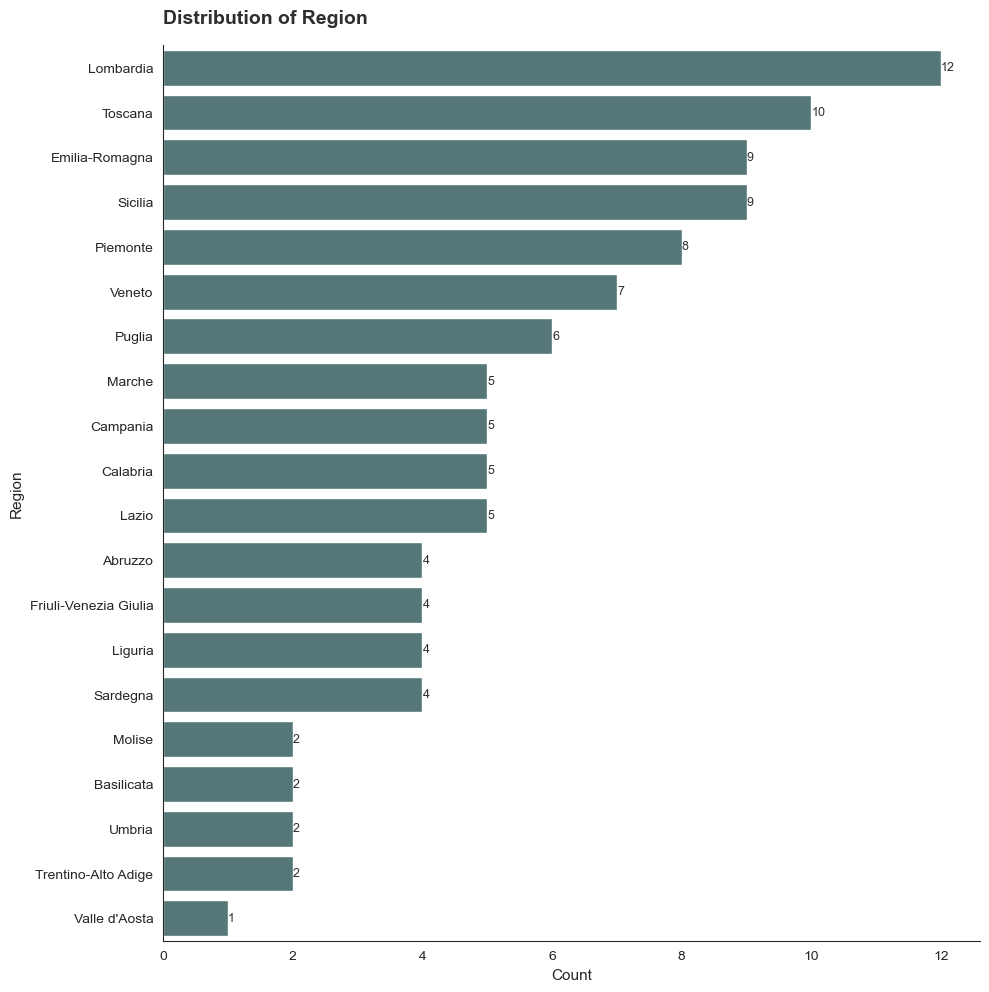

Detected type for 'N_CELLS': continuous
'N_CELLS': 0 missing (0.0%)
Skew: 0.968


,count,mean,std,min,25%,50%,75%,max
N_CELLS,106.0,47.132075,23.197321,8.0,32.0,43.0,56.75,112.0


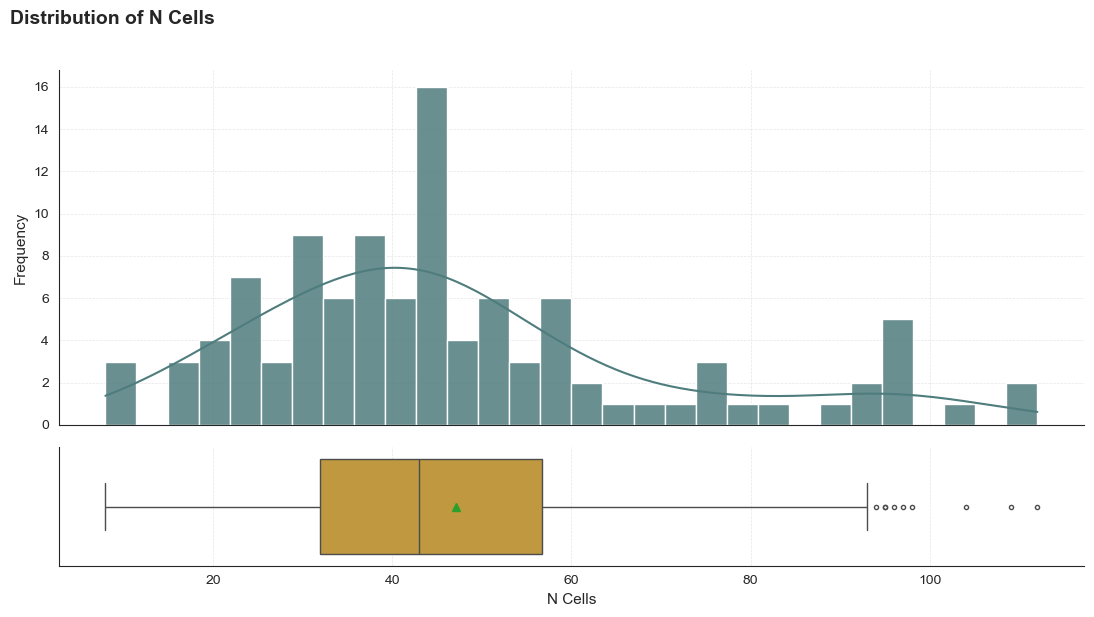

Detected type for 'ALTITUDE_MIN': continuous
'ALTITUDE_MIN': 0 missing (0.0%), 16 zeros (15.1%)
Skew: 1.747


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_MIN,106.0,46.90566,71.422623,0.0,1.0,9.0,63.5,321.0


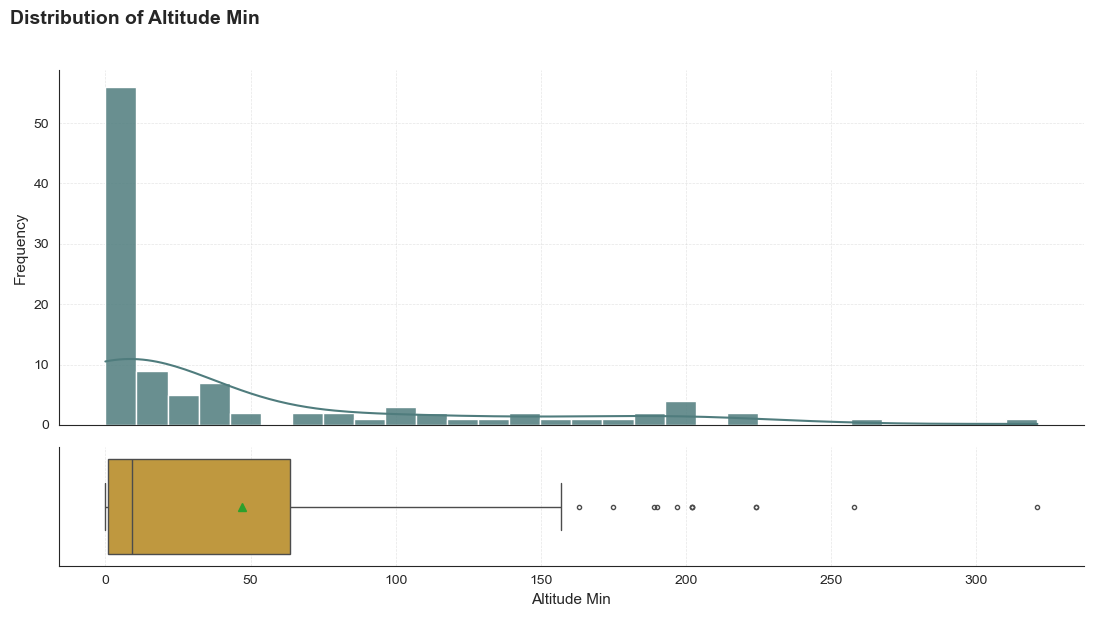

Detected type for 'ALTITUDE_MAX': continuous
'ALTITUDE_MAX': 0 missing (0.0%)
Skew: 1.053


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_MAX,106.0,1021.858491,652.470768,13.0,611.75,962.5,1303.75,2869.0


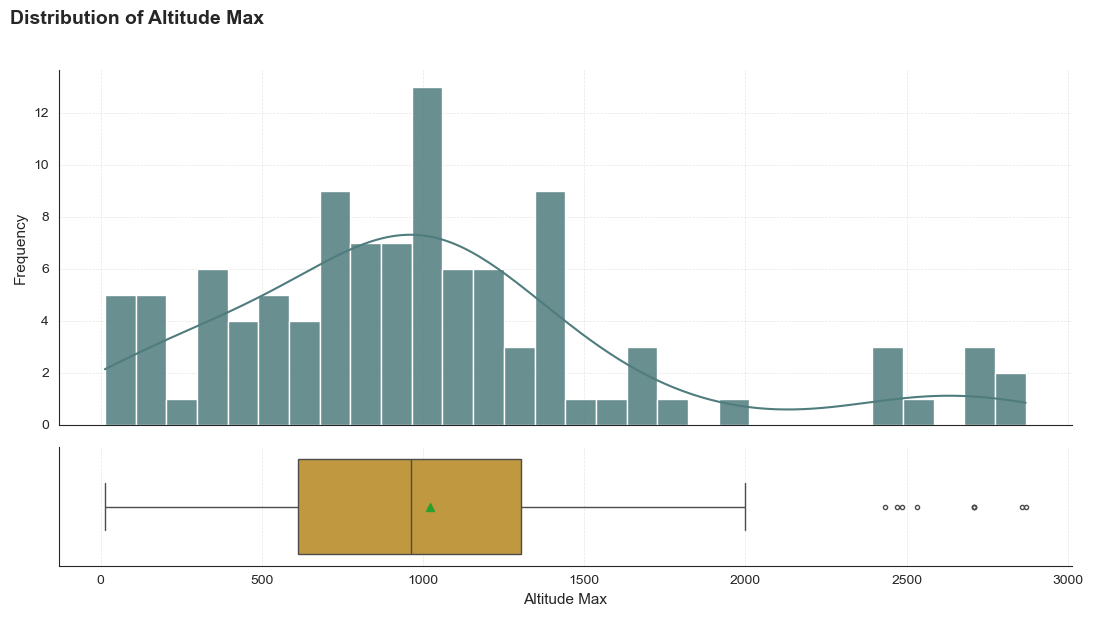

Detected type for 'ALTITUDE_RANGE': continuous
'ALTITUDE_RANGE': 0 missing (0.0%)
Skew: 0.919


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_RANGE,106.0,974.95283,616.25504,12.0,559.5,924.5,1208.5,2661.0


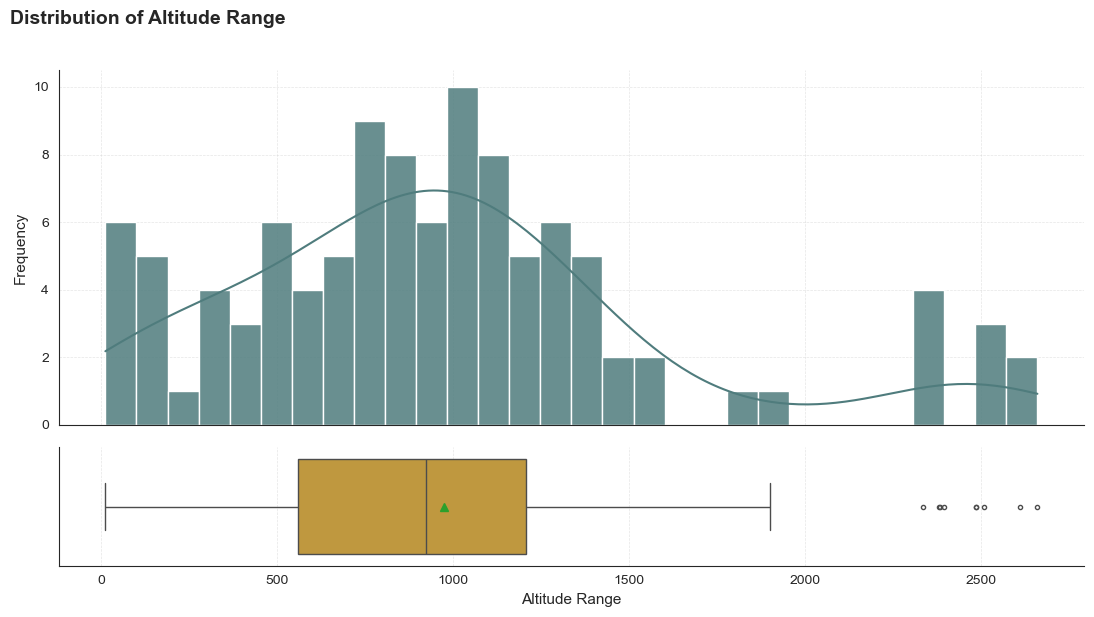

Detected type for 'ALTITUDE_MEAN': continuous
'ALTITUDE_MEAN': 0 missing (0.0%)
Skew: 2.335


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_MEAN,106.0,368.109783,306.307687,4.8125,199.371552,312.134167,432.380515,1817.45098


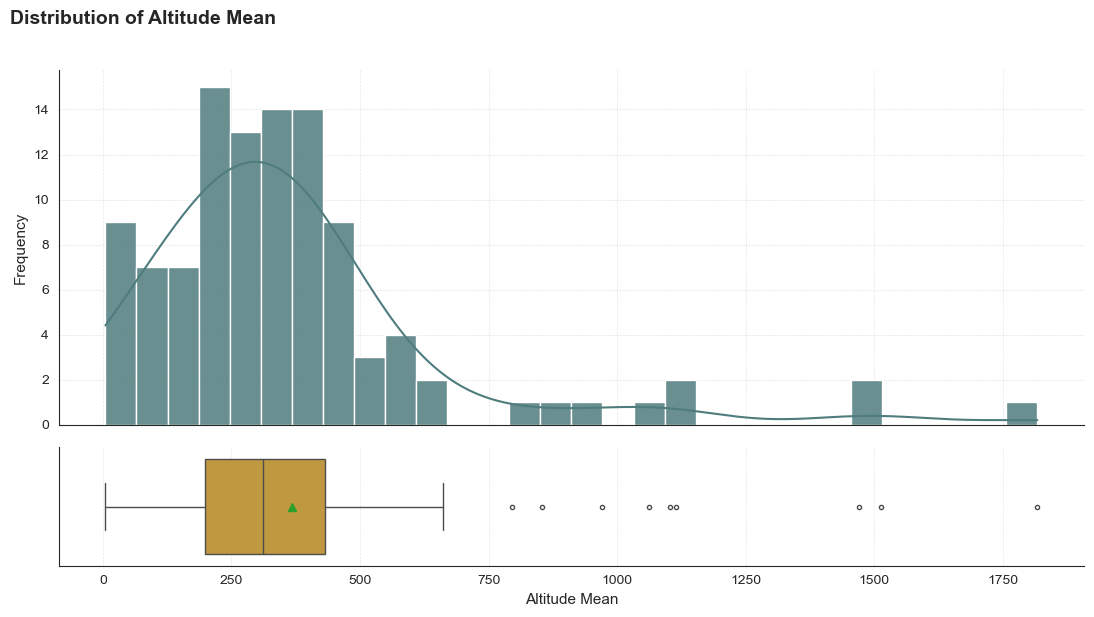

Detected type for 'ALTITUDE_STD': continuous
'ALTITUDE_STD': 0 missing (0.0%)
Skew: 0.957


,count,mean,std,min,25%,50%,75%,max
ALTITUDE_STD,106.0,265.241616,169.011165,3.963035,159.686041,244.386514,344.538002,796.279262


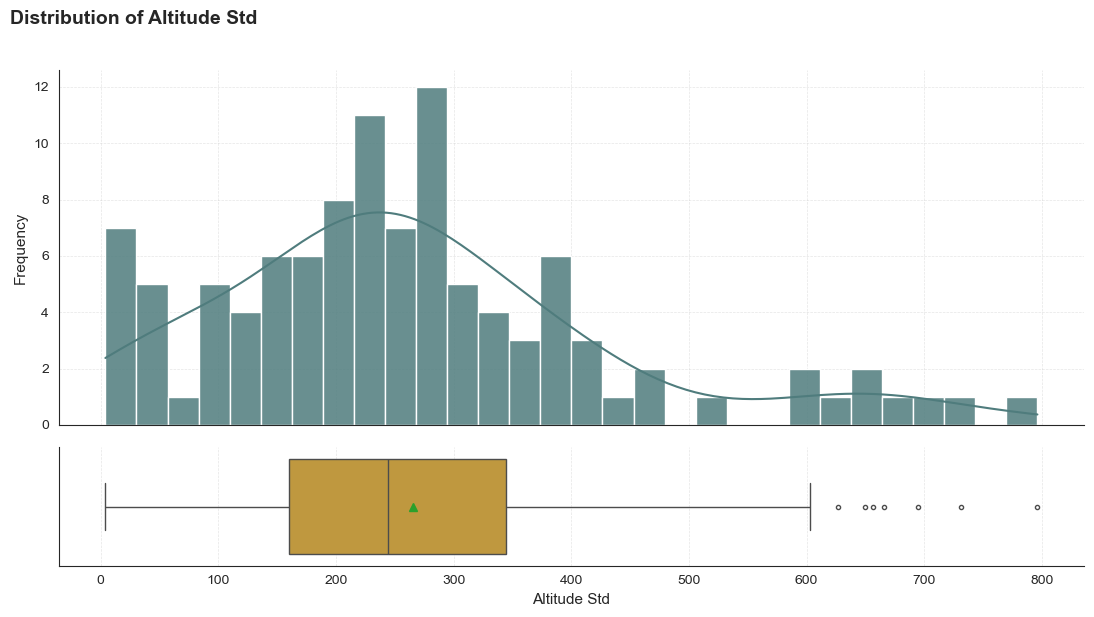

In [12]:
for c in provinces.columns[1:]:
    kind = infer_variable_type(provinces[c])
    if kind == "continuous":
        describe_variable(provinces, c, auto_log = False)
    else:
        describe_variable(provinces, c)

**PROVINCE ANALYSIS**

1. **Geographical composition**

The number of production areas differs across regions because Italian regions contain different numbers of provinces or equivalent administrative areas.

Lombardia is the most represented region, with 12 areas, followed by Toscana with 10 and by Emilia-Romagna and Sicilia with 9 each. Valle d’Aosta is represented by a single area.

These frequencies describe the administrative composition of the dataset. They should not be interpreted as sampling weights or as measures of the geographical or agricultural importance of the regions.

Since the subsequent dataset contains the same number of monthly observations for every province, regions with more provinces will nevertheless contribute more observations to statistics calculated over the complete national dataset.

2. **Number of grid cells**

Each production area is described by a variable number of grid cells, ranging from 8 to 112, with a median of 43 and a mean of 47. The distribution is moderately right-skewed (skew 0.94): most areas fall between 32 and 57 cells, while a small group of large southern and alpine provinces — Sassari (112), Bolzano (104), Area vasta Sud Sardegna (100), Potenza (98), Perugia (97) — extends the upper tail. Only 60 distinct values are observed across 106 areas, so several provinces share the same spatial support.

`N_CELLS` is essentially a proxy for administrative surface, not for agricultural relevance, and it must be read as the **sample size of every spatial aggregation** performed in the previous step. Three consequences follow, and they apply to the whole climate section of this notebook.

- All `*_AREA_FRACTION_*` variables are ratios of the form *k / N_CELLS*. Their resolution therefore depends on the province
- `TEMPERATURE_MAX_MONTH`, `TEMPERATURE_MIN_MONTH`, `PRECIPITATION_LOCAL_DAILY_MAX` and `WINDSPEED_LOCAL_MAX` are maxima (or minima) computed over *N_CELLS × OBSERVED_DAYS* values
- The strength of features like `TEMPERATURE_SPATIAL_STD_AVG` and `PRECIPITATION_SPATIAL_STD_AVG` strongly depends on the number of cells that have been considered to compute them

For these reasons `N_CELLS` is retained as a province-level contextual variable rather than discarded as metadata.

3. **Altitude and internal territorial heterogeneity**

The altitude variables show substantial differences among Italian production areas.

Minimum altitude is concentrated near sea level: the median is 9 metres and 17 areas have a minimum altitude equal to zero. This is consistent with the presence of coastal or low-lying grid cells in many provinces.

Maximum altitude is much more dispersed, with a median of approximately 963 metres and values reaching 2,869 metres. Consequently, several provinces include both lowland and mountainous cells.

Mean altitude is positively skewed. Most areas have a mean altitude below approximately 425 metres, while a limited number of provinces have considerably higher values.

Altitude range and altitude standard deviation confirm that many administrative areas are internally heterogeneous. Therefore, a single provincial mean altitude cannot fully represent their morphology. The simultaneous inclusion of mean altitude, standard deviation and range may help distinguish:

- predominantly flat areas;
- uniformly elevated areas;
- provinces combining plains, hills and mountains.

These variables are time-invariant and should be treated as province-level contextual predictors in subsequent modelling.

In [13]:
display(provinces.nlargest(10, "N_CELLS"))

,PROVINCE,REGION,N_CELLS,ALTITUDE_MIN,ALTITUDE_MAX,ALTITUDE_RANGE,ALTITUDE_MEAN,ALTITUDE_STD
83,Sassari,Sardegna,112,0,852,852,223.687500,193.815647
73,Area vasta Sud Sardegna,Sardegna,109,0,1013,1013,174.018349,215.775646
72,Provincia Autonoma di Bolzano / Autonome Provi...,Trentino-Alto Adige,104,224,2710,2486,1513.951923,602.613698
70,Potenza,Basilicata,98,39,1150,1111,595.663265,239.059021
63,Perugia,Umbria,97,189,1353,1164,439.000000,227.947499
23,Cosenza,Calabria,96,0,1389,1389,465.270833,408.125019
26,Cuneo,Piemonte,95,135,2470,2335,853.957895,656.106811
31,Foggia,Puglia,95,0,729,729,213.968421,214.471565
91,Torino,Piemonte,94,149,2533,2384,971.297872,796.279262
93,Trento,Trentino-Alto Adige,93,224,2710,2486,1103.225806,595.368449


### Climate data - Univariate Analysis

The table below shows the descriptive statistics for each climate information column: it pools 58,512 observations obtained by crossing 106 production areas with 552 consecutive months. Each marginal distribution is therefore a **mixture over two dimensions**: the seasonal cycle (twelve monthly regimes) and the geographical gradient (from alpine to Mediterranean areas).

This has a direct consequence on interpretation. The bimodality visible in `TEMPERATURE_AVG_MONTH`, `RADIATION_DAILY_AVG`, `RADIATION_TOTAL_MONTH` and `ET0_TOTAL_MONTH` is not an anomaly and not evidence of two populations of provinces: it is the winter/summer alternation of a strongly seasonal panel observed in aggregate. Similarly, the apparent dispersion of temperature and precipitation reflects both when and where the observation was taken.

Univariate analysis at this stage is therefore used to verify plausibility, completeness and the structural properties of each variable (support, zero inflation, discreteness, ceiling effects). Any statement about the climatic behaviour of Italian production areas requires conditioning on month and on geography, which is done in the following sections.

In [14]:
pd.set_option('display.max_rows', None)
display(df[climate_cols].describe(include = 'all').T)
pd.reset_option('display.max_rows')

,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_AVG_MONTH,58512.0,13.713433,7.075590,-8.558634,8.194055,13.332396,19.786838,29.009302
TEMPERATURE_MAX_MONTH,58512.0,26.962473,7.448628,8.500000,20.700000,26.800000,33.200000,50.100000
TEMPERATURE_MIN_MONTH,58512.0,-0.337374,7.959925,-36.600000,-5.600000,-0.400000,5.900000,19.400000
PRECIPITATION_DAILY_AVG,58512.0,2.091006,1.778572,0.000000,0.828205,1.674546,2.857686,22.566667
PRECIPITATION_LOCAL_DAILY_MAX,58512.0,33.355278,26.009550,0.000000,16.000000,27.000000,43.000000,309.000000
WINDSPEED_AVG_MONTH,58512.0,2.545378,0.964750,0.220222,1.844541,2.404432,3.156296,9.245674
WINDSPEED_LOCAL_MAX,58512.0,8.902584,3.708981,1.200000,6.200000,8.300000,10.900000,33.200000
VAPOURPRESSURE_AVG_MONTH,58512.0,12.439507,4.860364,2.292157,8.407971,11.770770,16.361075,28.018755
ET0_DAILY_AVG,58512.0,2.704101,1.641751,0.188387,1.243671,2.461306,4.057924,7.434327
RADIATION_DAILY_AVG,58512.0,14959.739761,7352.516221,2467.922379,7994.667248,14778.700941,21705.419039,32191.586111


**Deterministic relationships between variables**

Several variables are not independent measurements but algebraic transformations of one another. Identifying them now avoids duplicated information and collinearity in the modelling phase.

**Monthly totals and daily averages.** With a mean month length of 30.44 days, the observed averages are consistent with an exact relationship *total ≈ daily average × observed days*:

| Pair | daily avg × 30.44 | observed monthly total |
|---|---|---|
| Precipitation | 63.65 | 63.61 |
| ET0 | 82.31 | 82.54 |
| Radiation | 455,347 | 456,182 |

The three `*_TOTAL_MONTH` variables therefore carry almost no information beyond their daily counterparts, except for the number of days in the month — which is itself a deterministic function of the calendar. One of the two forms should be kept, preferring daily averages when comparing months of different length.

**Wet and dry days.** `WET_DAYS_AREA_MEAN` and `DRY_DAYS_AREA_MEAN` sum to 30.44 on average, i.e. exactly the number of observed days: they are complementary by construction and only one of the two should be retained.

**Coverage of the same phenomenon at different thresholds.** `DAYS_FROST_ANY_AREA` / `DAYS_FROST_10PCT`, `DAYS_HOT_30_ANY_AREA` / `DAYS_HOT_30_10PCT`, `DAYS_HOT_35_ANY_AREA` / `DAYS_HOT_35_10PCT` and the pairs *extreme / very extreme* are nested by construction: the second term of each pair is always less than or equal to the first. They describe the same event at two levels of severity and are expected to be strongly correlated; the correlation analysis will quantify how much independent information the stricter definition adds.

'TEMPERATURE_AVG_MONTH': 0 missing (0.0%)
Skew: -0.059


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_AVG_MONTH,58512.0,13.713433,7.07559,-8.558634,8.194055,13.332396,19.786838,29.009302


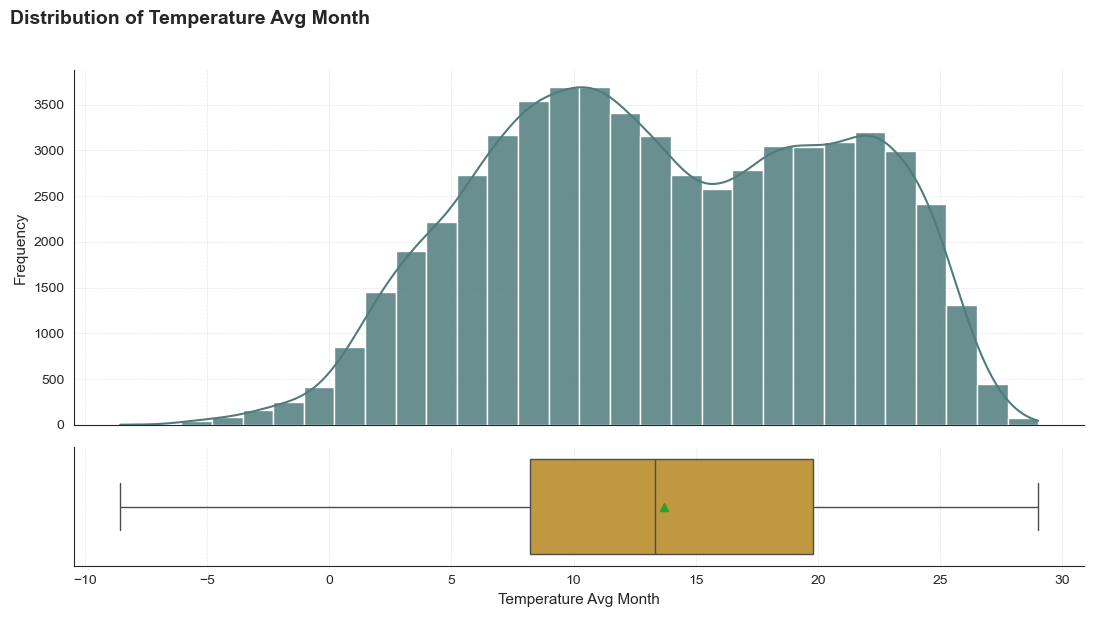

'TEMPERATURE_MAX_MONTH': 0 missing (0.0%)
Skew: 0.029


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_MAX_MONTH,58512.0,26.962473,7.448628,8.5,20.7,26.8,33.2,50.1


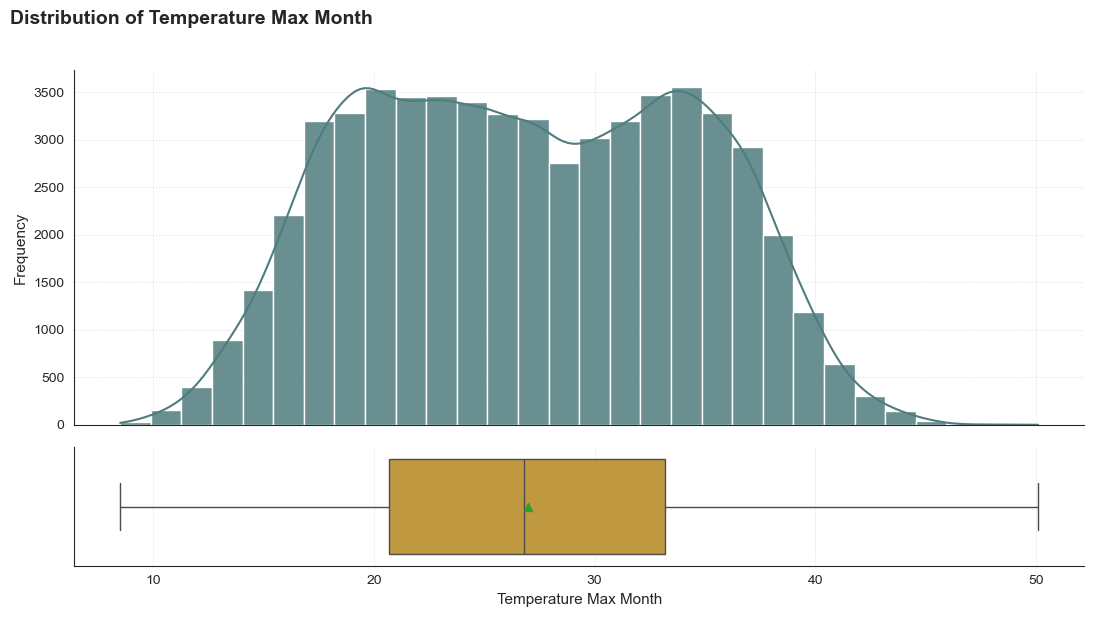

'TEMPERATURE_MIN_MONTH': 0 missing (0.0%), 296 zeros (0.5%)
Skew: -0.330


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_MIN_MONTH,58512.0,-0.337374,7.959925,-36.6,-5.6,-0.4,5.9,19.4


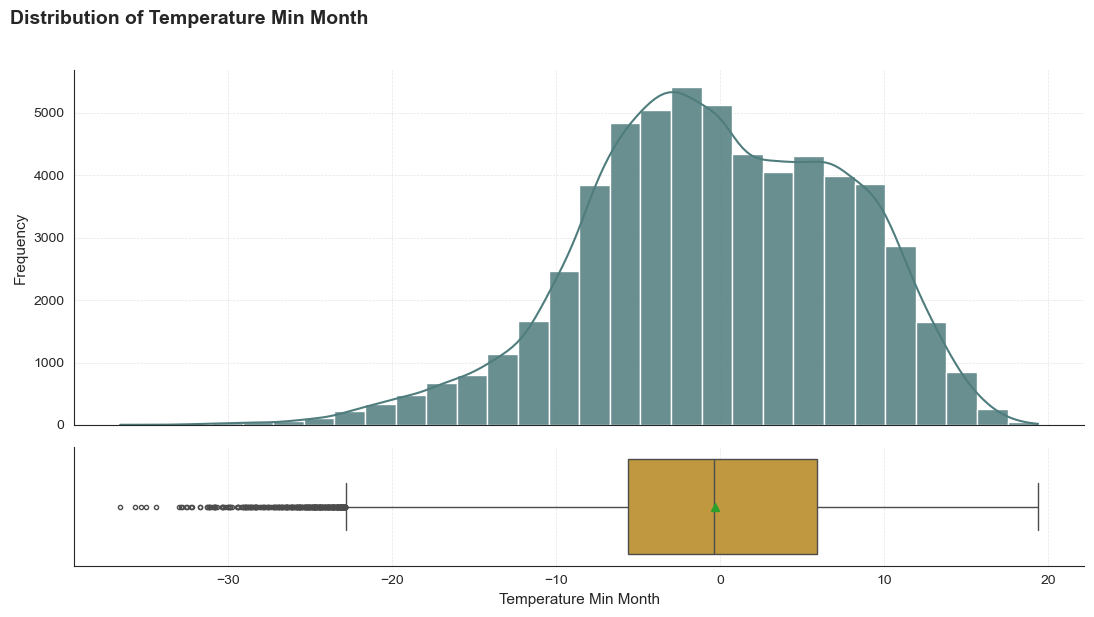

'PRECIPITATION_DAILY_AVG': 0 missing (0.0%), 161 zeros (0.3%)
Skew: 1.983


,count,mean,std,min,25%,50%,75%,max
PRECIPITATION_DAILY_AVG,58512.0,2.091006,1.778572,0.0,0.828205,1.674546,2.857686,22.566667


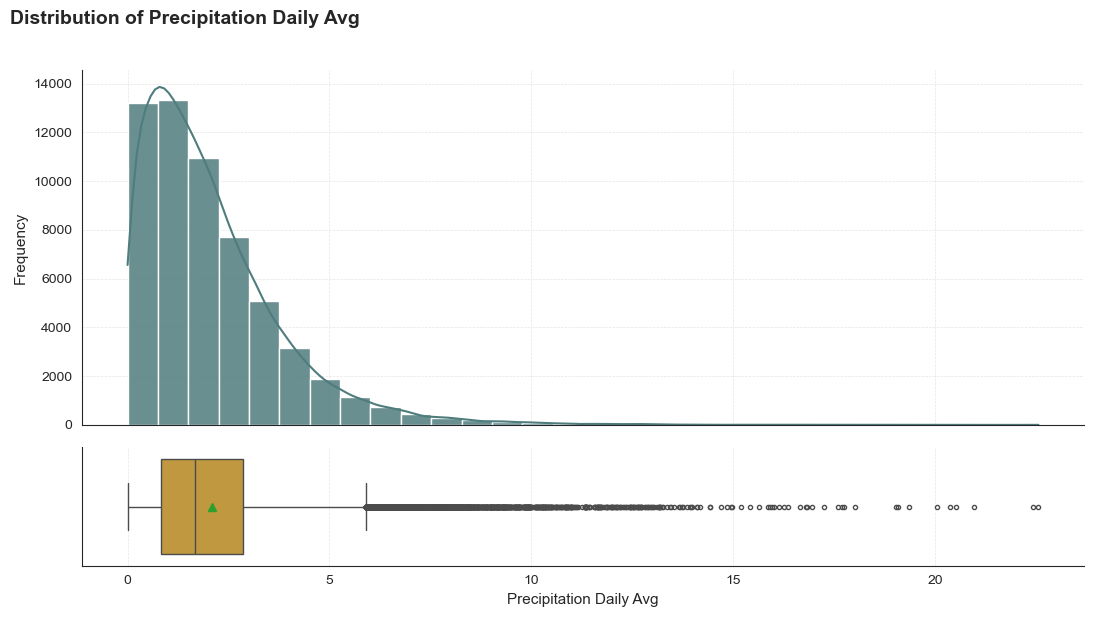

'PRECIPITATION_LOCAL_DAILY_MAX': 0 missing (0.0%), 161 zeros (0.3%)
Skew: 2.267


,count,mean,std,min,25%,50%,75%,max
PRECIPITATION_LOCAL_DAILY_MAX,58512.0,33.355278,26.00955,0.0,16.0,27.0,43.0,309.0


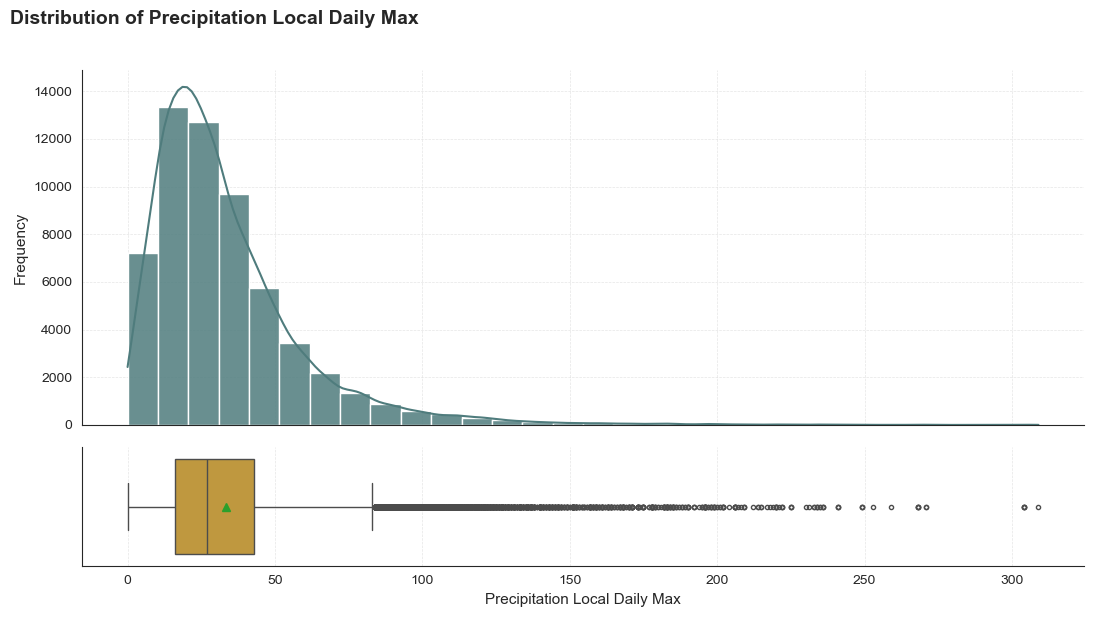

'WINDSPEED_AVG_MONTH': 0 missing (0.0%)
Skew: 0.658


,count,mean,std,min,25%,50%,75%,max
WINDSPEED_AVG_MONTH,58512.0,2.545378,0.96475,0.220222,1.844541,2.404432,3.156296,9.245674


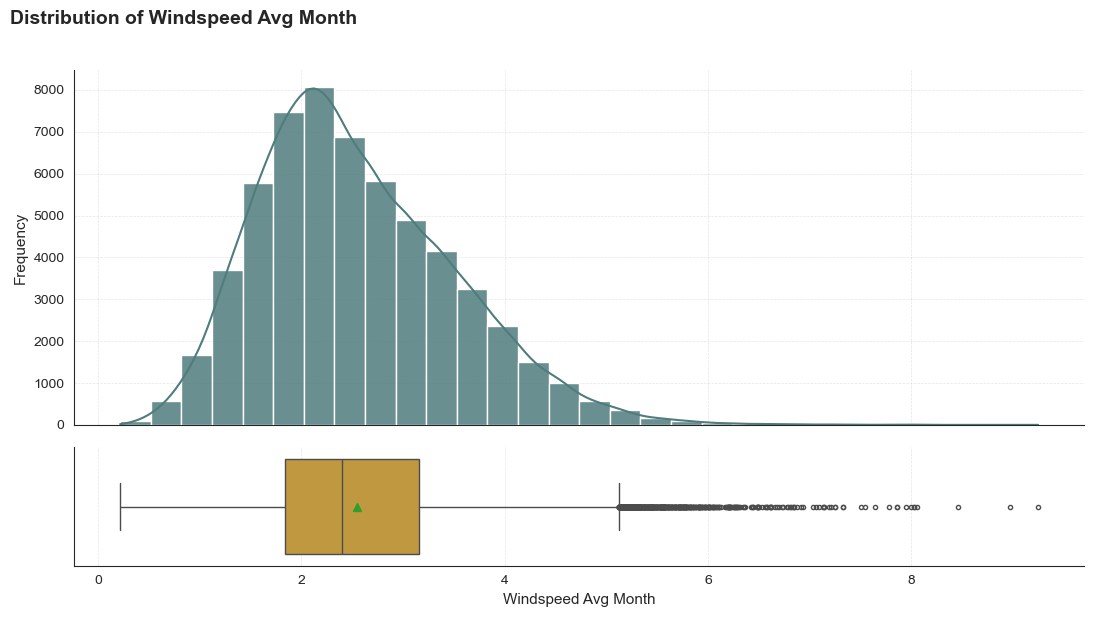

'WINDSPEED_LOCAL_MAX': 0 missing (0.0%)
Skew: 1.130


,count,mean,std,min,25%,50%,75%,max
WINDSPEED_LOCAL_MAX,58512.0,8.902584,3.708981,1.2,6.2,8.3,10.9,33.2


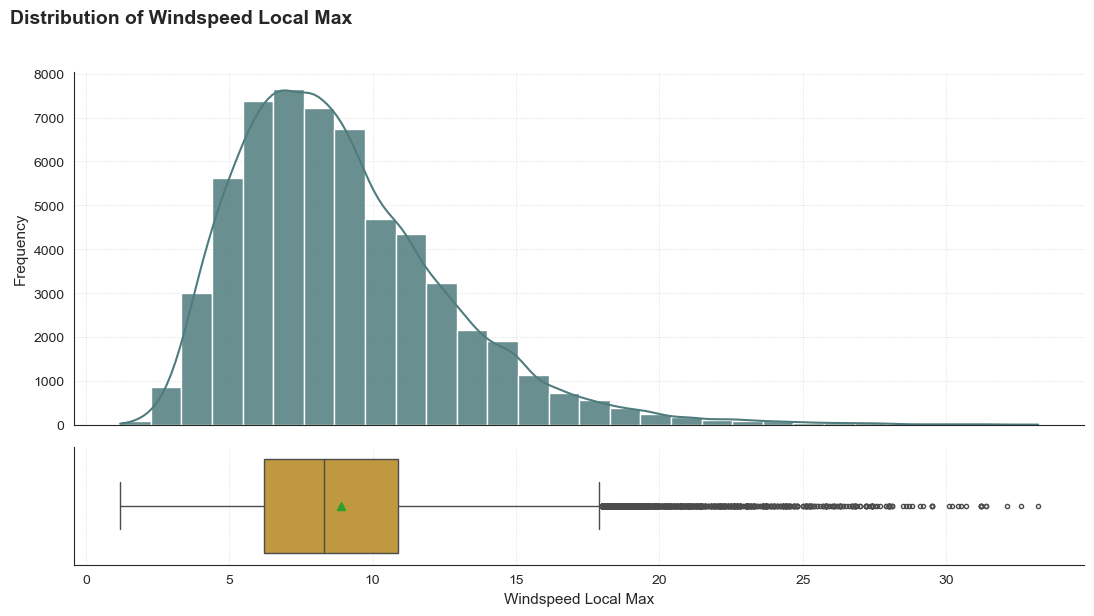

'VAPOURPRESSURE_AVG_MONTH': 0 missing (0.0%)
Skew: 0.310


,count,mean,std,min,25%,50%,75%,max
VAPOURPRESSURE_AVG_MONTH,58512.0,12.439507,4.860364,2.292157,8.407971,11.77077,16.361075,28.018755


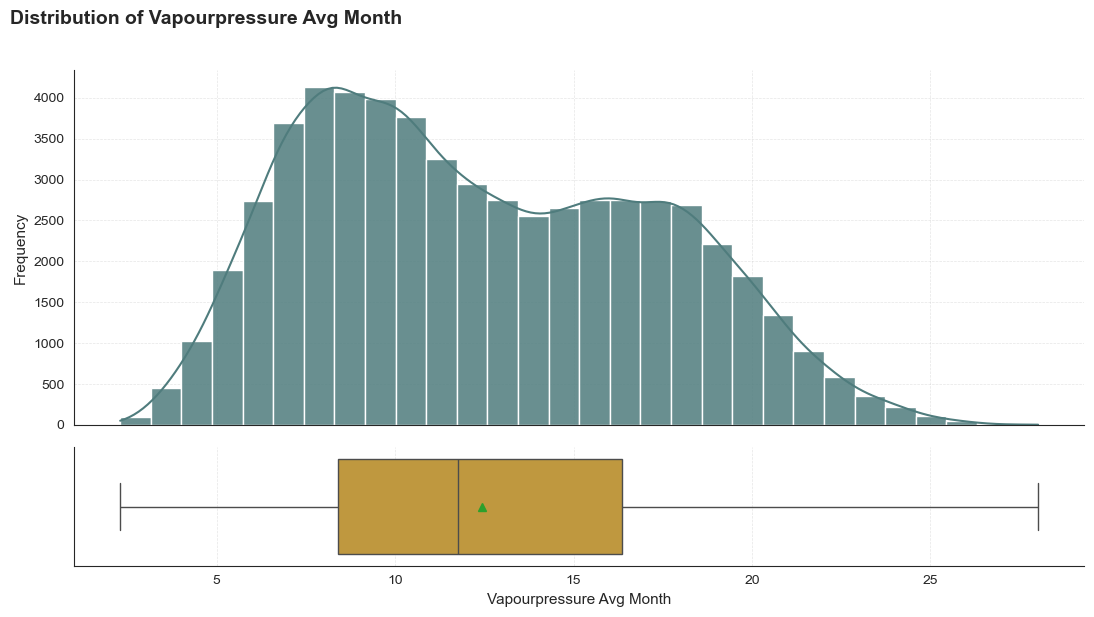

'ET0_DAILY_AVG': 0 missing (0.0%)
Skew: 0.409


,count,mean,std,min,25%,50%,75%,max
ET0_DAILY_AVG,58512.0,2.704101,1.641751,0.188387,1.243671,2.461306,4.057924,7.434327


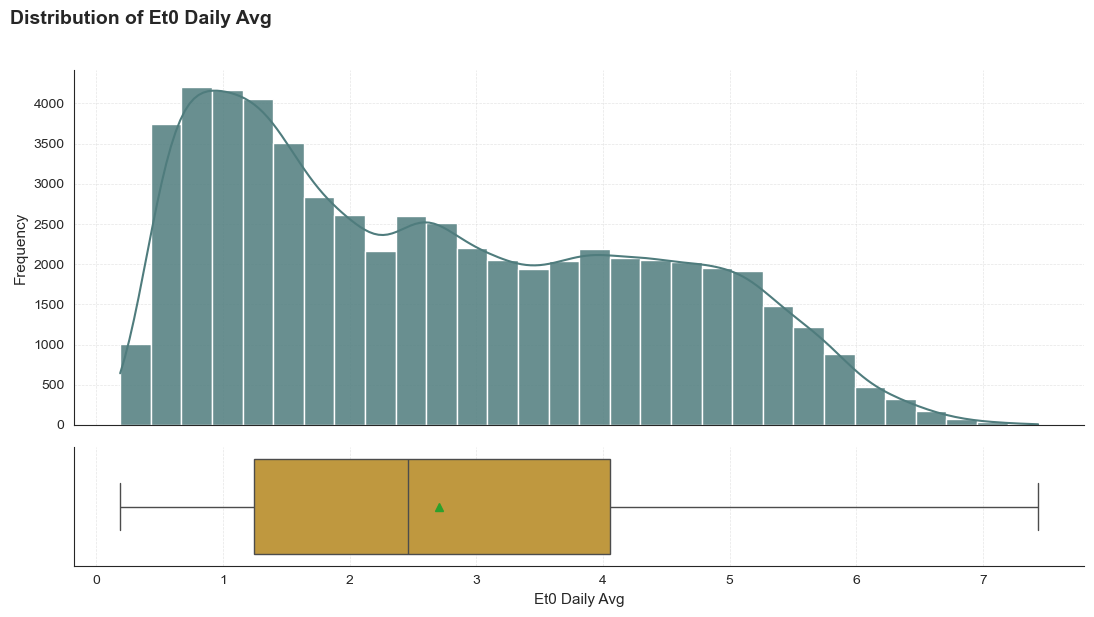

'RADIATION_DAILY_AVG': 0 missing (0.0%)
Skew: 0.106


,count,mean,std,min,25%,50%,75%,max
RADIATION_DAILY_AVG,58512.0,14959.739761,7352.516221,2467.922379,7994.667248,14778.700941,21705.419039,32191.586111


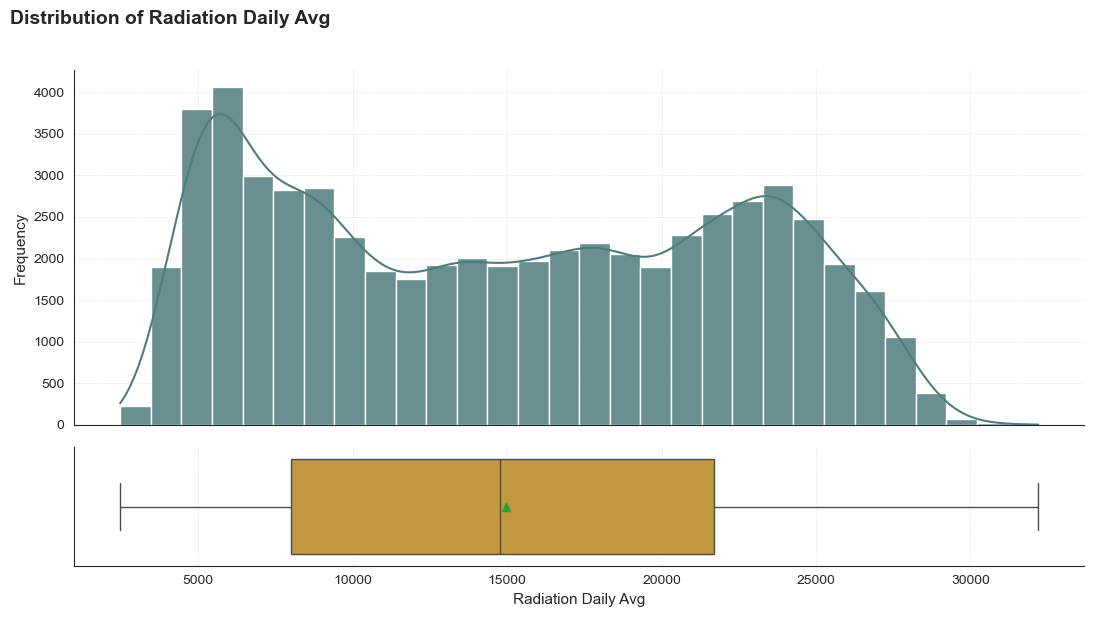

'PRECIPITATION_TOTAL_MONTH': 0 missing (0.0%), 161 zeros (0.3%)
Skew: 1.967


,count,mean,std,min,25%,50%,75%,max
PRECIPITATION_TOTAL_MONTH,58512.0,63.607624,54.097269,0.0,25.178478,50.902492,86.871976,677.0


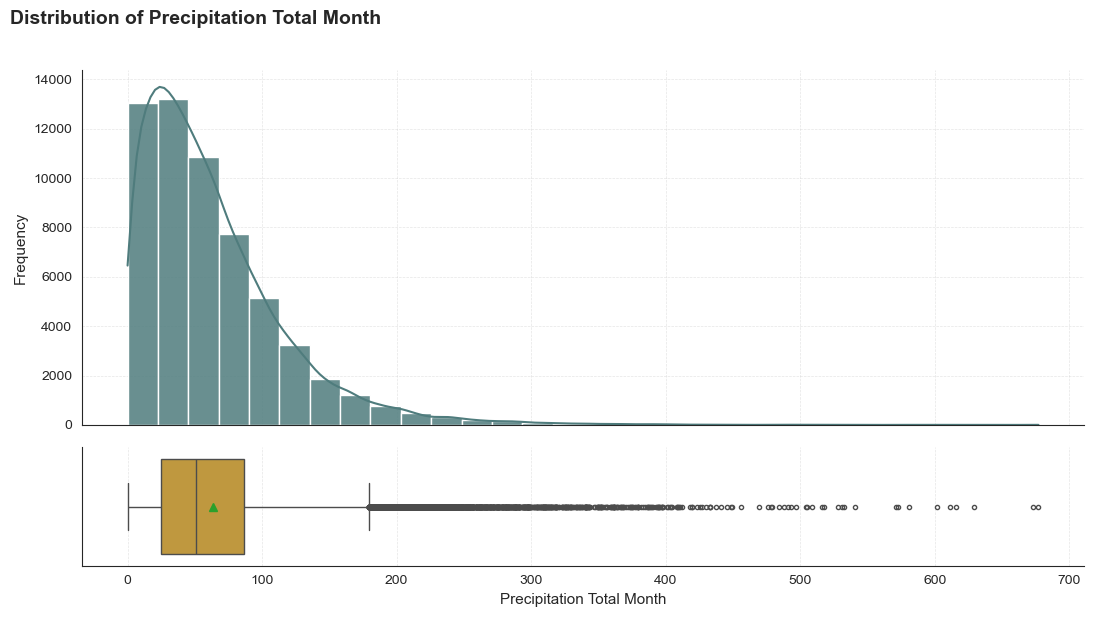

'ET0_TOTAL_MONTH': 0 missing (0.0%)
Skew: 0.426


,count,mean,std,min,25%,50%,75%,max
ET0_TOTAL_MONTH,58512.0,82.547046,50.580959,5.84,37.313043,74.829825,124.505689,230.464151


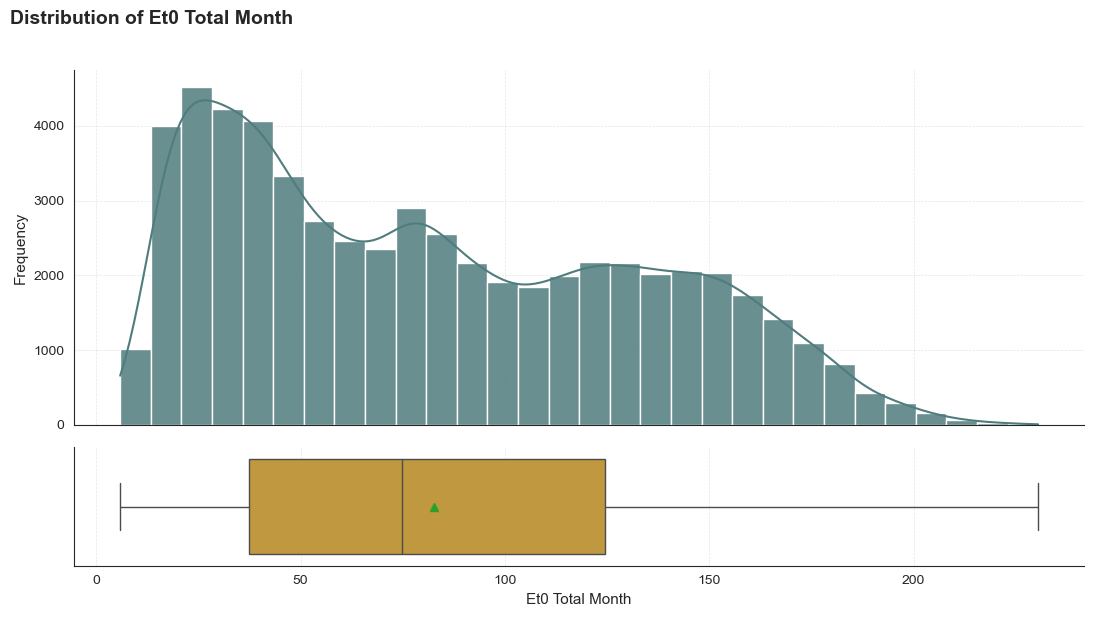

'RADIATION_TOTAL_MONTH': 0 missing (0.0%)
Skew: 0.122


,count,mean,std,min,25%,50%,75%,max
RADIATION_TOTAL_MONTH,58512.0,456181.031278,226551.960895,76505.59375,237072.491953,450887.090705,668173.133571,987516.375


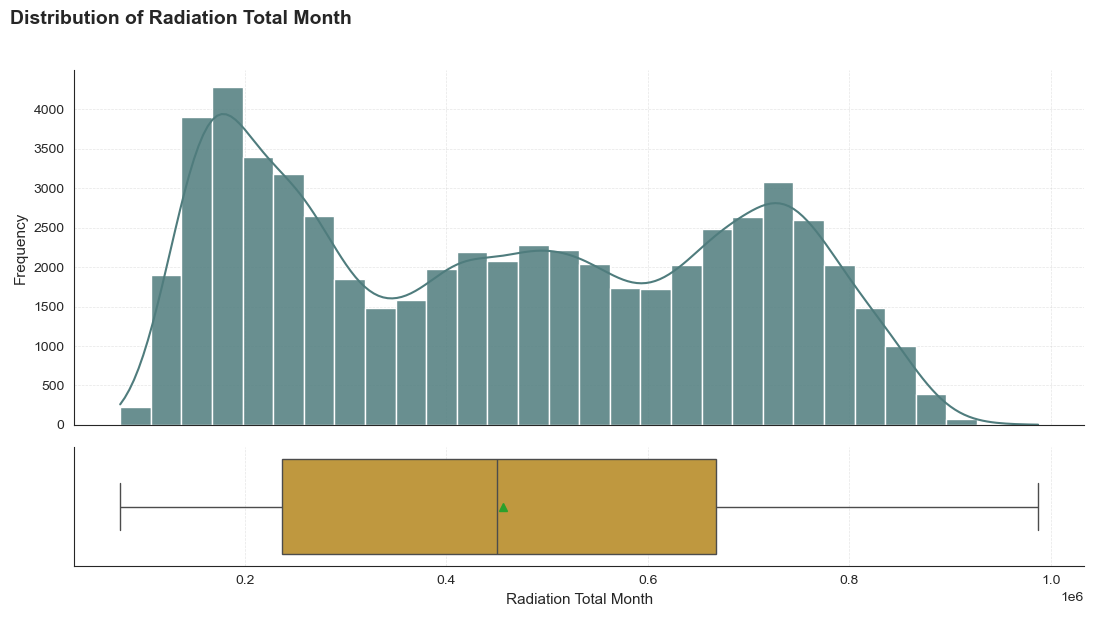

'TEMPERATURE_DAILY_STD': 0 missing (0.0%)
Skew: 0.879


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_DAILY_STD,58512.0,2.354396,0.725823,0.570044,1.845773,2.261047,2.76498,6.761704


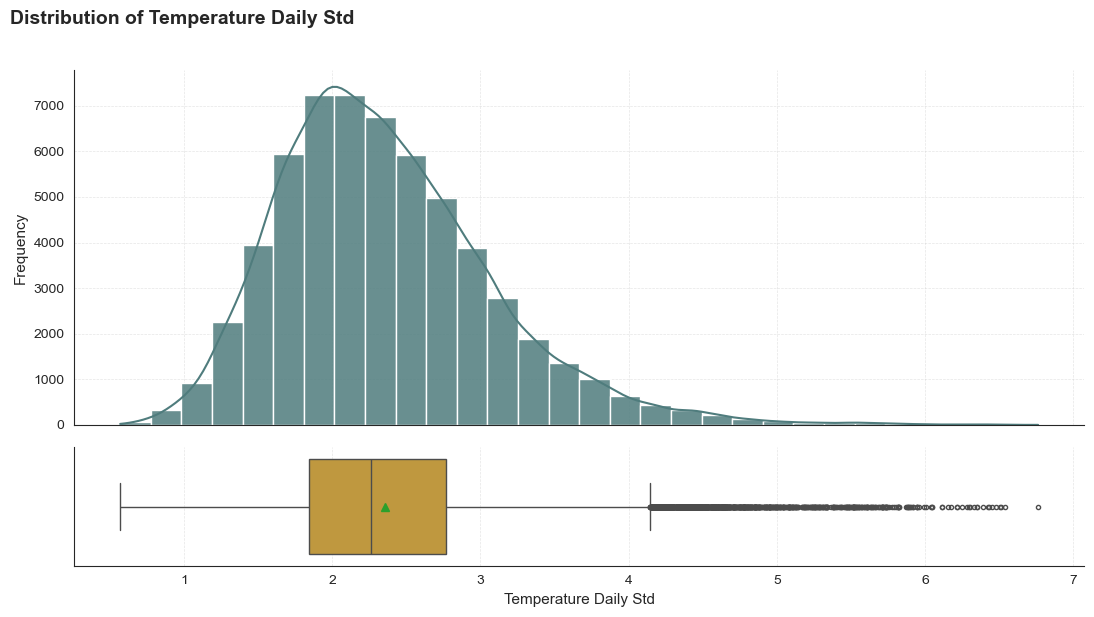

'TEMPERATURE_SPATIAL_STD_AVG': 0 missing (0.0%)
Skew: 1.243


,count,mean,std,min,25%,50%,75%,max
TEMPERATURE_SPATIAL_STD_AVG,58512.0,1.698439,0.939492,0.141508,1.060677,1.507697,2.094745,5.869416


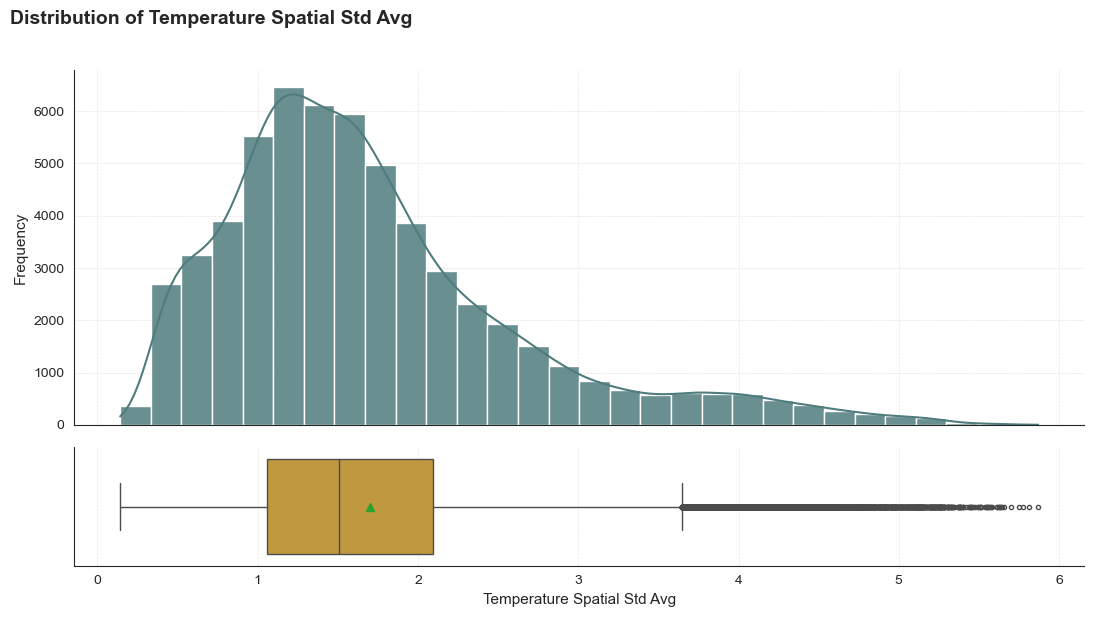

'PRECIPITATION_AREA_DAILY_MAX': 0 missing (0.0%), 161 zeros (0.3%)
Skew: 2.042


,count,mean,std,min,25%,50%,75%,max
PRECIPITATION_AREA_DAILY_MAX,58512.0,18.05862,14.525174,0.0,8.090909,14.5625,24.0,205.947368


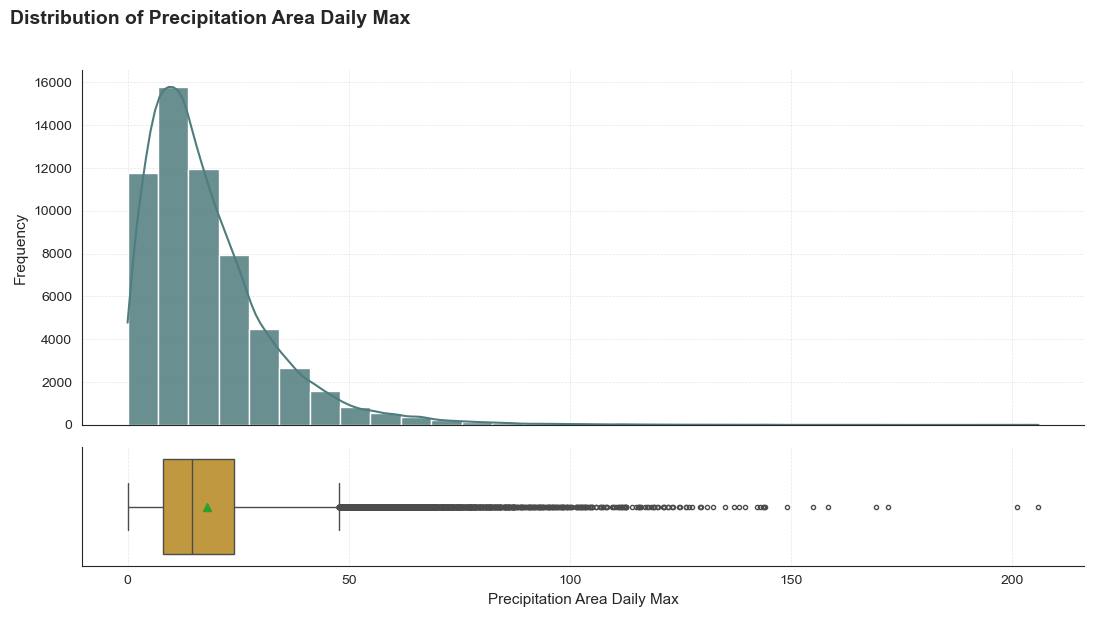

'PRECIPITATION_SPATIAL_STD_AVG': 0 missing (0.0%), 168 zeros (0.3%)
Skew: 1.820


,count,mean,std,min,25%,50%,75%,max
PRECIPITATION_SPATIAL_STD_AVG,58512.0,1.014715,0.779508,0.0,0.470199,0.833193,1.359836,10.067683


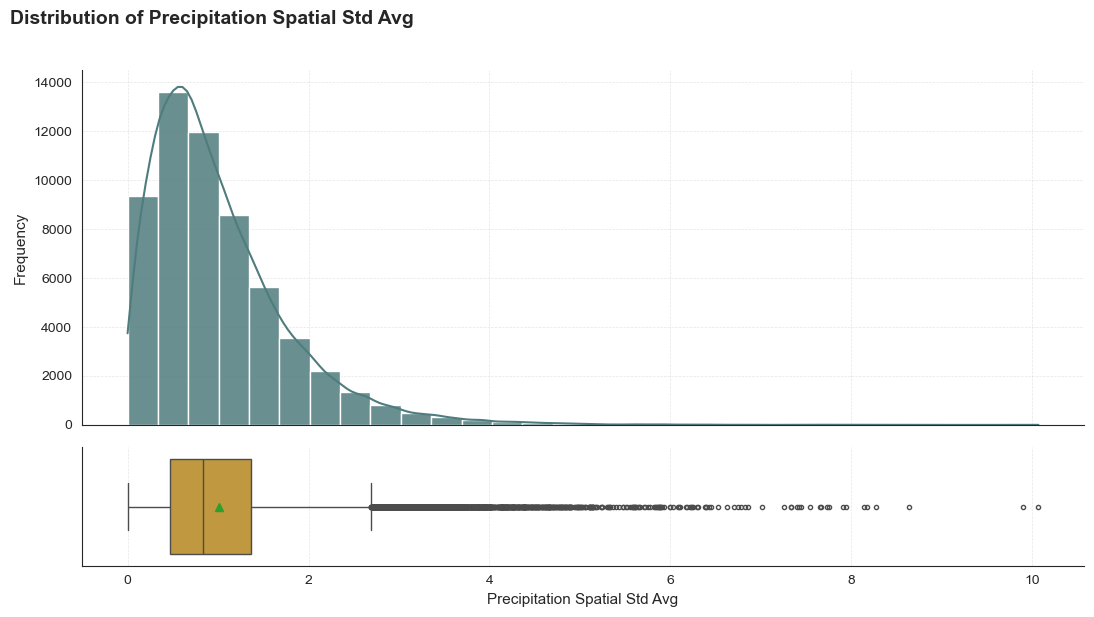

'WET_DAYS_AREA_MEAN': 0 missing (0.0%), 1354 zeros (2.3%)
Skew: 0.403


,count,mean,std,min,25%,50%,75%,max
WET_DAYS_AREA_MEAN,58512.0,8.893372,4.909643,0.0,5.0,9.0,12.0,31.0


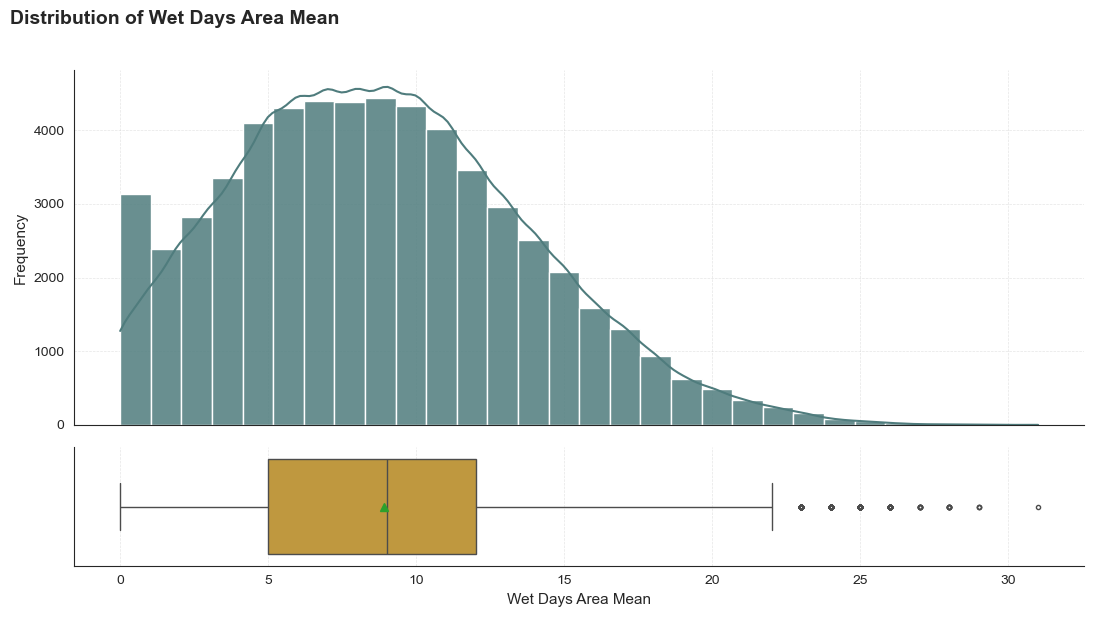

'WET_DAYS_SPATIAL': 0 missing (0.0%), 312 zeros (0.5%)
Skew: 0.075


,count,mean,std,min,25%,50%,75%,max
WET_DAYS_SPATIAL,58512.0,13.480756,5.898509,0.0,9.0,13.0,18.0,31.0


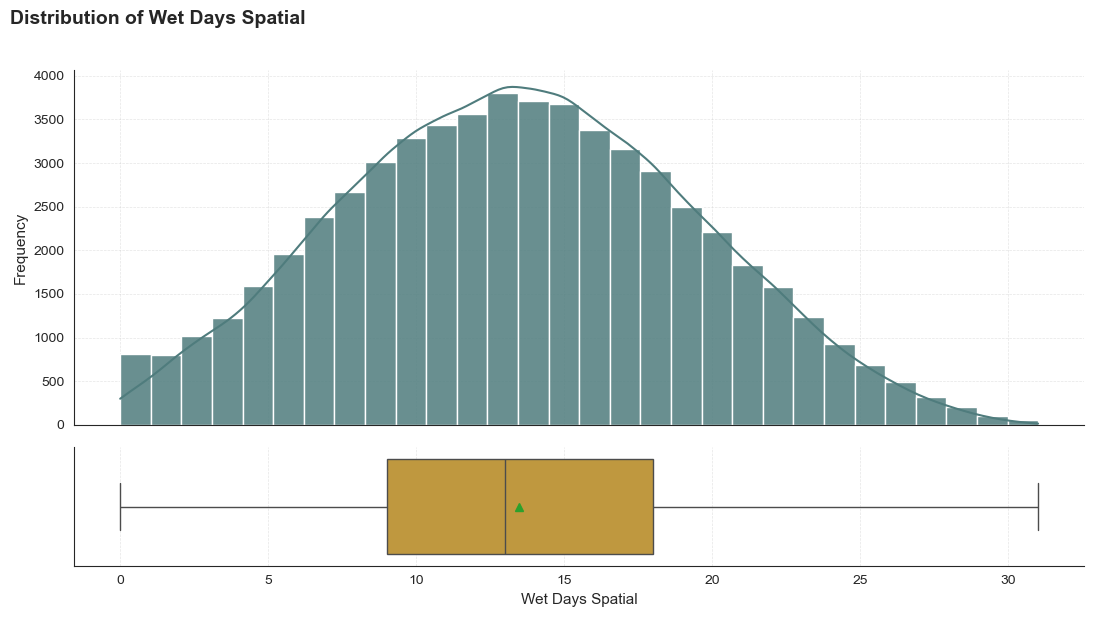

'DRY_DAYS_AREA_MEAN': 0 missing (0.0%), 1 zeros (0.0%)
Skew: -0.358


,count,mean,std,min,25%,50%,75%,max
DRY_DAYS_AREA_MEAN,58512.0,21.545033,4.970015,0.0,18.0,22.0,25.0,31.0


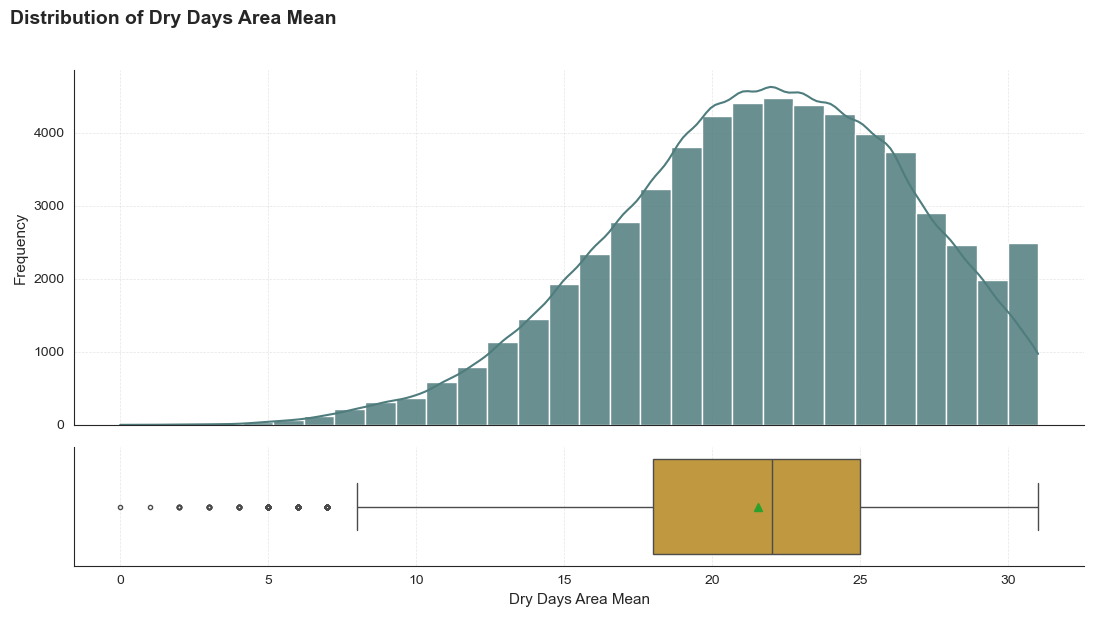

'DRY_DAYS_ALL_CELLS': 0 missing (0.0%), 84 zeros (0.1%)
Skew: 0.066


,count,mean,std,min,25%,50%,75%,max
DRY_DAYS_ALL_CELLS,58512.0,15.192251,6.19757,0.0,11.0,15.0,20.0,31.0


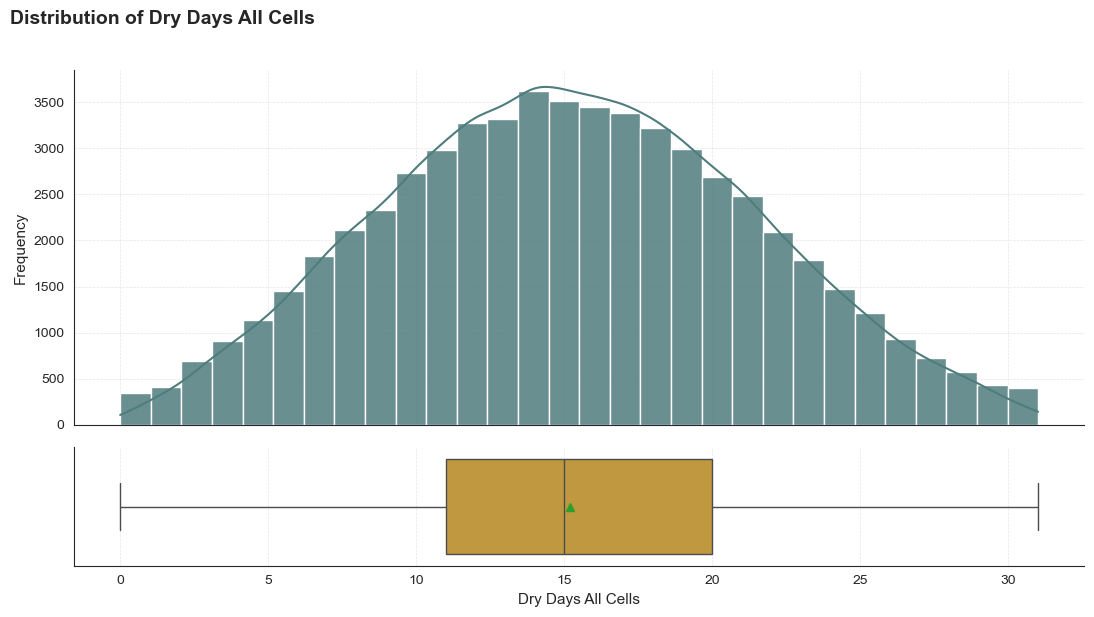

'WET_AREA_FRACTION_AVG': 0 missing (0.0%), 161 zeros (0.3%)
Skew: 0.267


,count,mean,std,min,25%,50%,75%,max
WET_AREA_FRACTION_AVG,58512.0,0.321956,0.158635,0.0,0.204762,0.315804,0.429542,0.957576


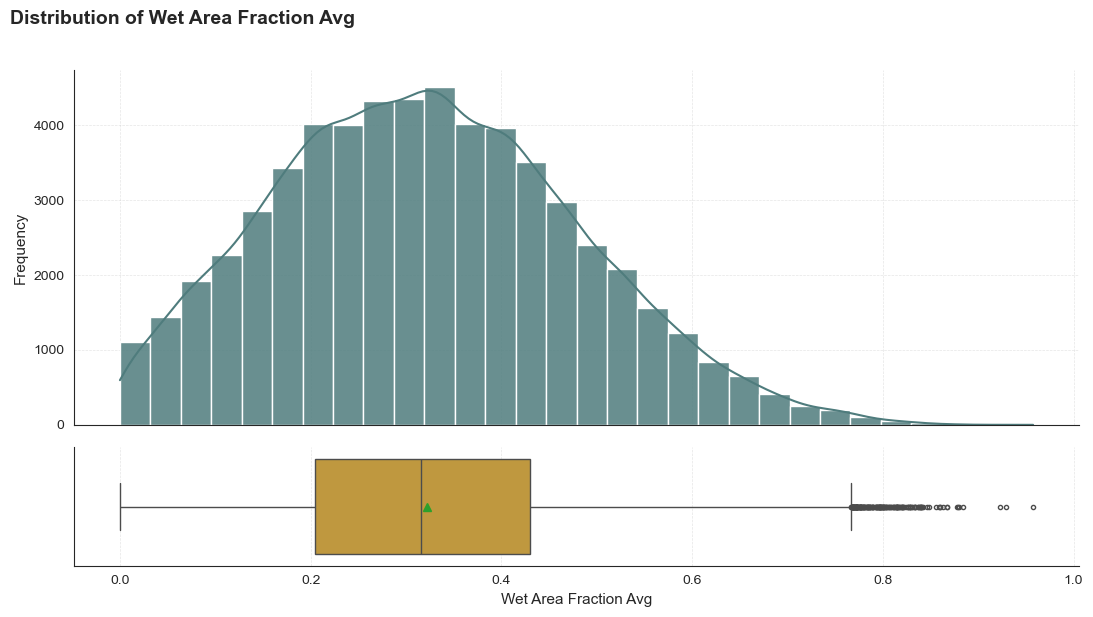

'WET_AREA_FRACTION_MAX': 0 missing (0.0%), 161 zeros (0.3%)
Skew: -6.236


,count,mean,std,min,25%,50%,75%,max
WET_AREA_FRACTION_MAX,58512.0,0.977173,0.113325,0.0,1.0,1.0,1.0,1.0


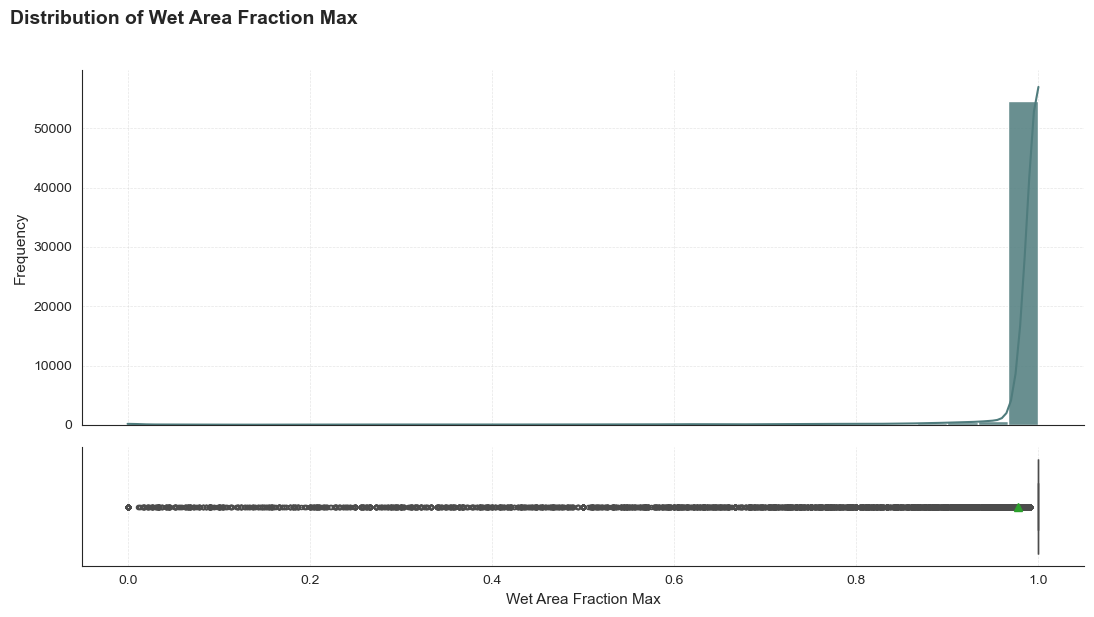

'WET_AREA_WHEN_PRESENT': 0 missing (0.0%), 161 zeros (0.3%)
Skew: -0.648


,count,mean,std,min,25%,50%,75%,max
WET_AREA_WHEN_PRESENT,58512.0,0.625277,0.160411,0.0,0.531006,0.640344,0.737465,1.0


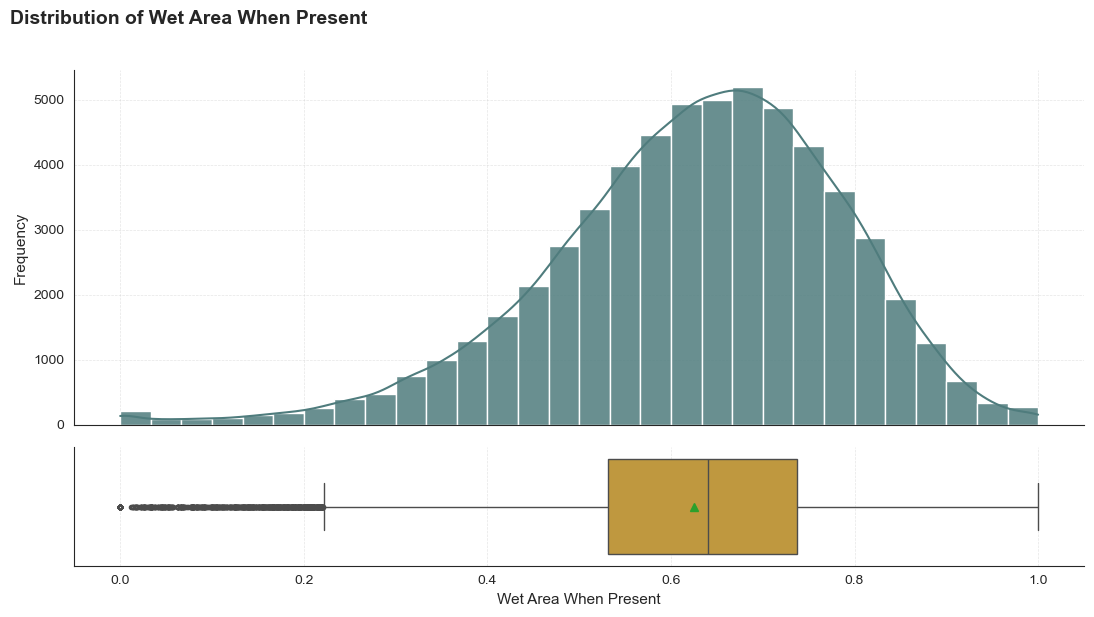

'DAYS_RAIN_20': 0 missing (0.0%), 25142 zeros (43.0%)


,Days Rain 20,abs_freq,rel_freq_%
0,0,25142,42.97
1,1,14109,24.11
2,2,8369,14.30
3,3,4795,8.19
4,4,2796,4.78
5,5,1583,2.71
6,6,827,1.41
7,7,441,0.75
8,8,222,0.38
9,9,112,0.19


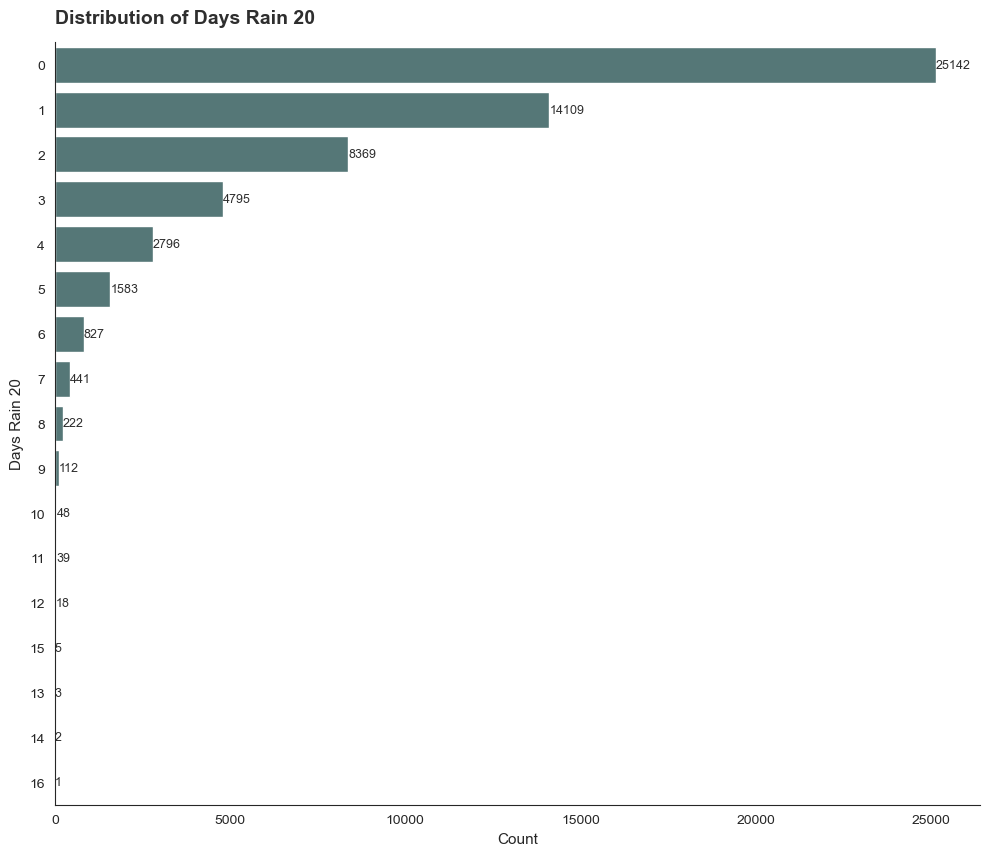

'DAYS_RAIN_50': 0 missing (0.0%), 51657 zeros (88.3%)


,Days Rain 50,abs_freq,rel_freq_%
0,0,51657,88.28
1,1,5090,8.70
2,2,1190,2.03
3,3,426,0.73
4,4,87,0.15
5,5,36,0.06
6,6,18,0.03
7,7,7,0.01
8,8,1,0.00


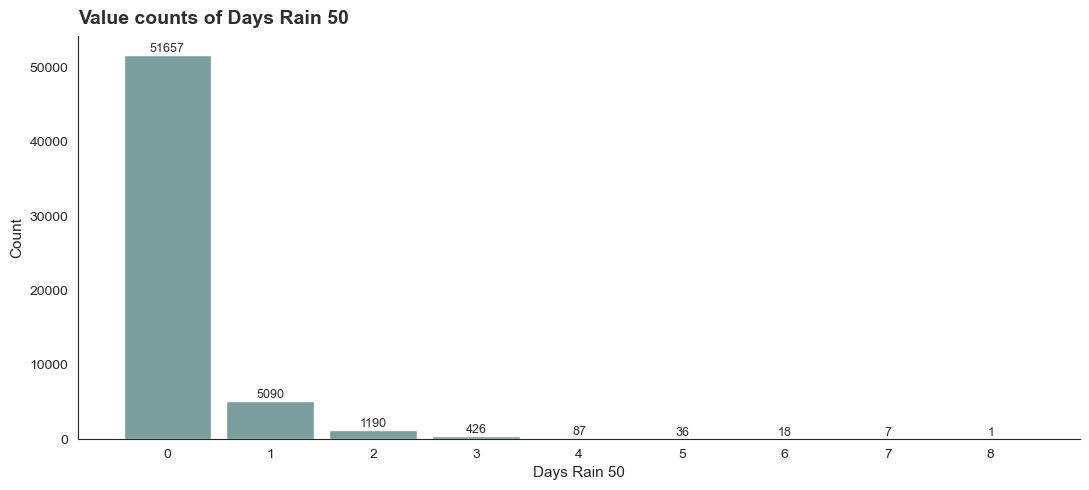

'RAIN_20_AREA_FRACTION_MAX': 0 missing (0.0%), 19150 zeros (32.7%)
Skew: 0.592


,count,mean,std,min,25%,50%,75%,max
RAIN_20_AREA_FRACTION_MAX,58512.0,0.355385,0.380536,0.0,0.0,0.189873,0.717531,1.0


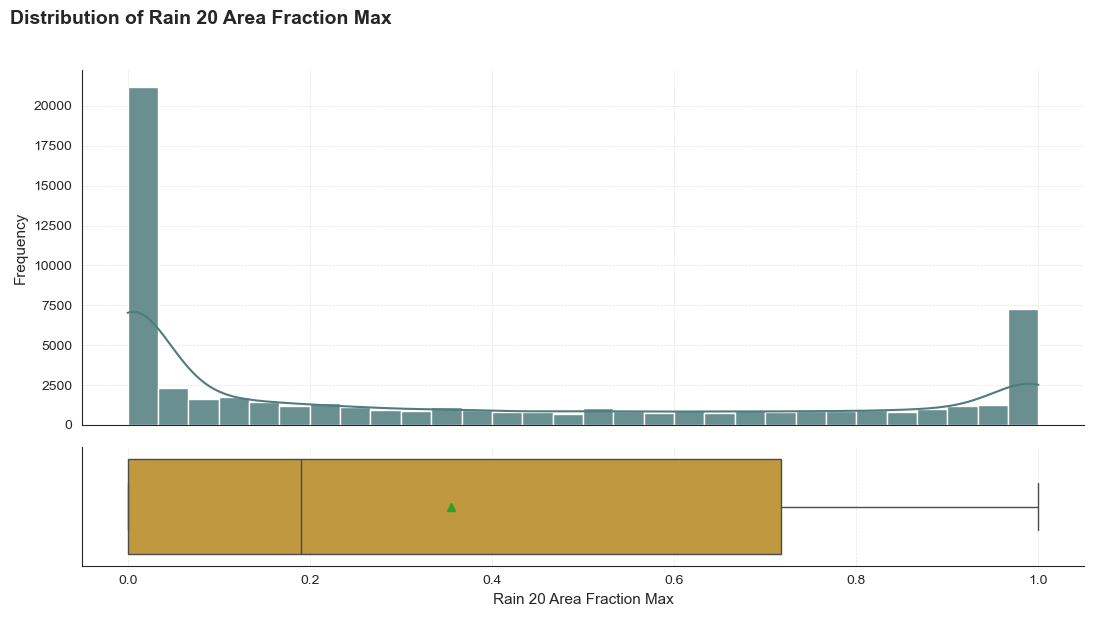

'RAIN_50_AREA_FRACTION_MAX': 0 missing (0.0%), 47757 zeros (81.6%)
Skew: 3.966


,count,mean,std,min,25%,50%,75%,max
RAIN_50_AREA_FRACTION_MAX,58512.0,0.050652,0.159633,0.0,0.0,0.0,0.0,1.0


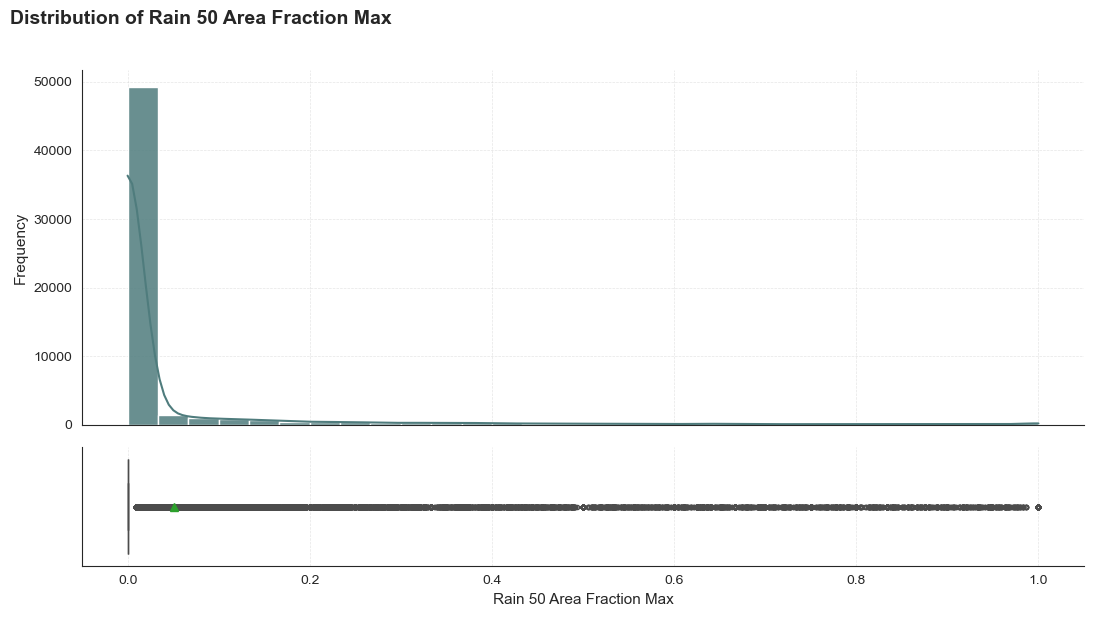

'DAYS_EXTREME_RAIN': 0 missing (0.0%), 24626 zeros (42.1%)


,Days Extreme Rain,abs_freq,rel_freq_%
0,0,24626,42.09
1,1,15938,27.24
2,2,9257,15.82
3,3,4696,8.03
4,4,2230,3.81
5,5,1024,1.75
6,6,436,0.75
7,7,178,0.30
8,8,86,0.15
9,9,28,0.05


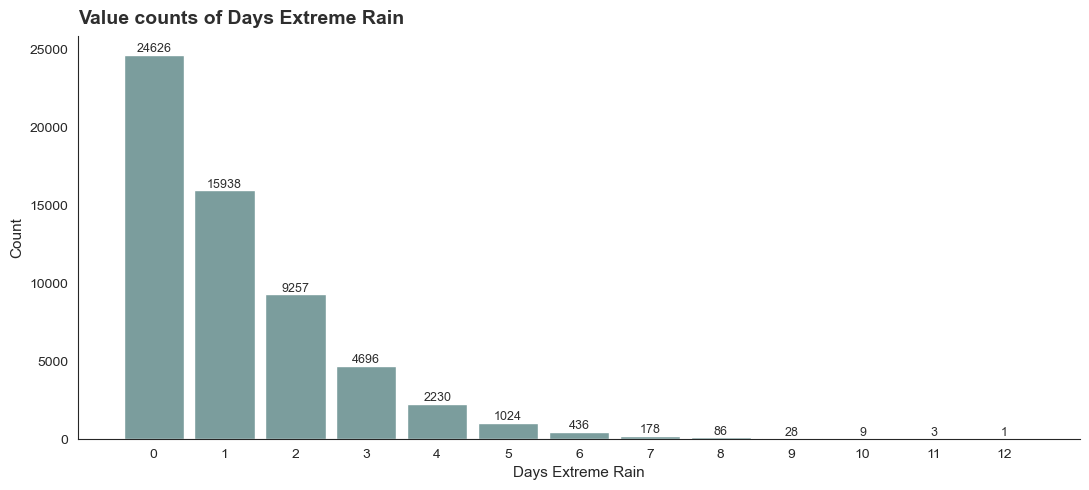

'DAYS_VERY_EXTREME_RAIN': 0 missing (0.0%), 44487 zeros (76.0%)


,Days Very Extreme Rain,abs_freq,rel_freq_%
0,0,44487,76.03
1,1,10337,17.67
2,2,2740,4.68
3,3,713,1.22
4,4,165,0.28
5,5,48,0.08
6,6,16,0.03
7,7,5,0.01
8,8,1,0.00


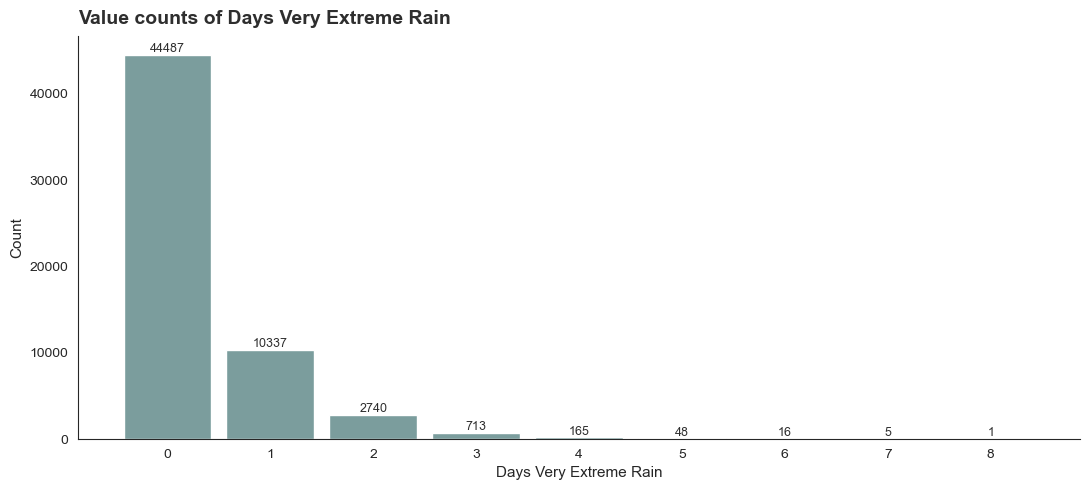

'EXTREME_RAIN_AREA_FRACTION_AVG': 0 missing (0.0%), 18160 zeros (31.0%)
Skew: 1.966


,count,mean,std,min,25%,50%,75%,max
EXTREME_RAIN_AREA_FRACTION_AVG,58512.0,0.018192,0.024115,0.0,0.0,0.008065,0.029412,0.232975


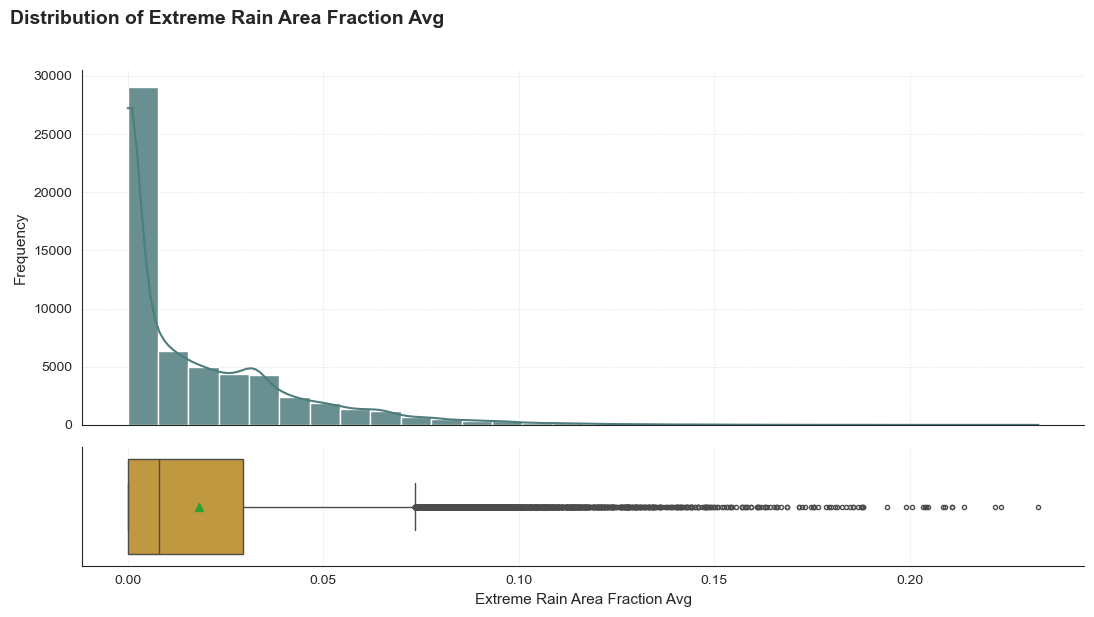

'EXTREME_RAIN_AREA_FRACTION_MAX': 0 missing (0.0%), 18160 zeros (31.0%)
Skew: 0.687


,count,mean,std,min,25%,50%,75%,max
EXTREME_RAIN_AREA_FRACTION_MAX,58512.0,0.333198,0.357461,0.0,0.0,0.189655,0.631579,1.0


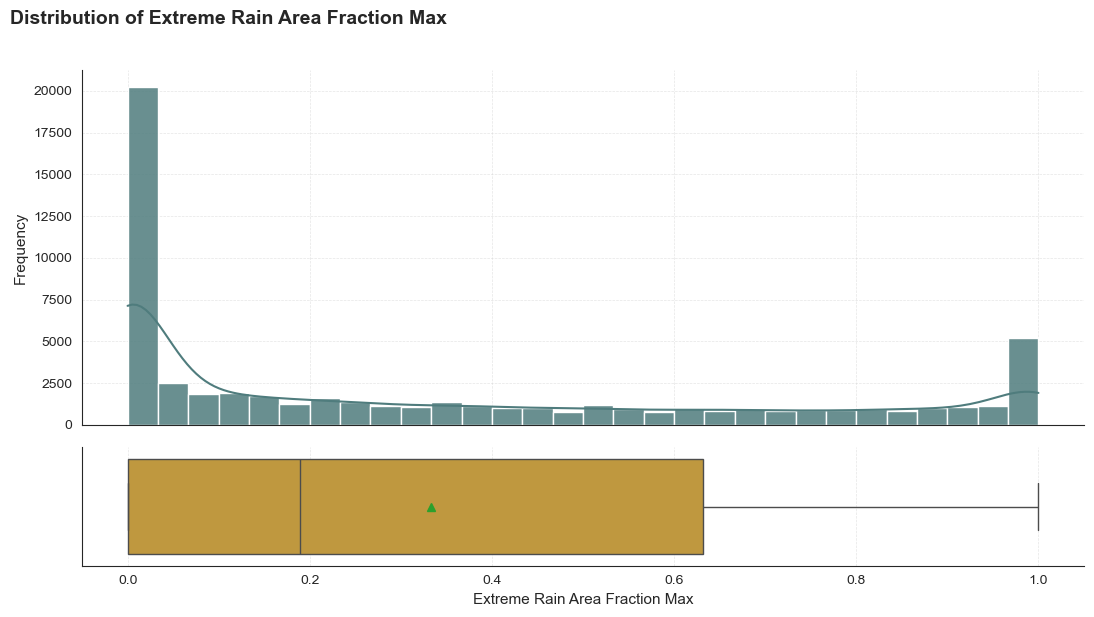

'EXTREME_RAIN_AREA_WHEN_PRESENT': 0 missing (0.0%), 18160 zeros (31.0%)
Skew: 1.205


,count,mean,std,min,25%,50%,75%,max
EXTREME_RAIN_AREA_WHEN_PRESENT,58512.0,0.222165,0.253089,0.0,0.0,0.135593,0.364286,1.0


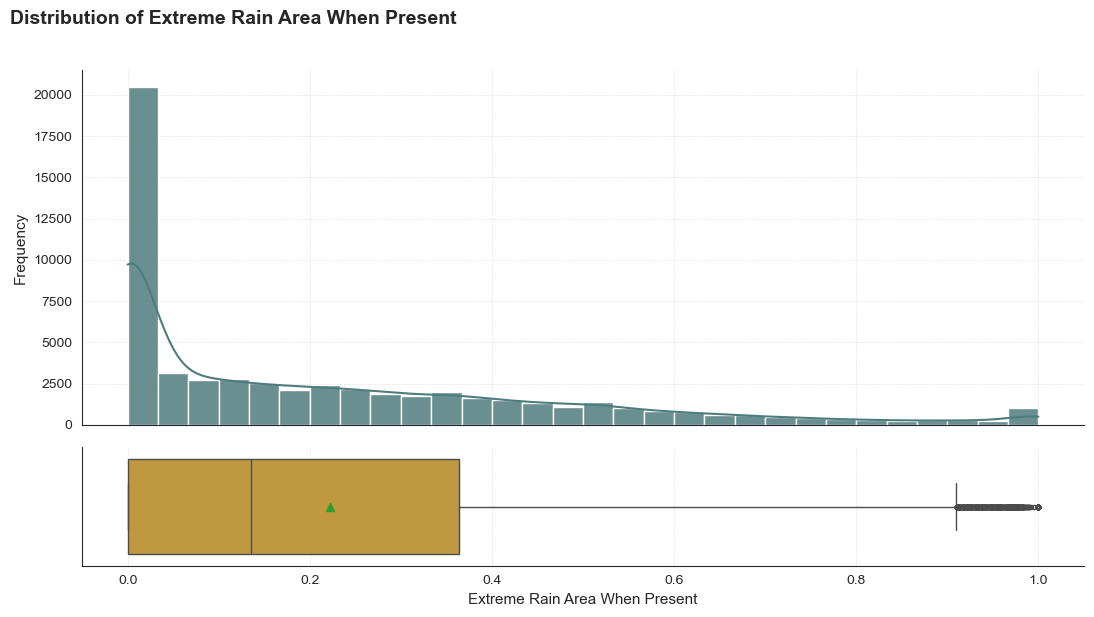

'VERY_EXTREME_RAIN_AREA_FRACTION_MAX': 0 missing (0.0%), 37633 zeros (64.3%)
Skew: 2.489


,count,mean,std,min,25%,50%,75%,max
VERY_EXTREME_RAIN_AREA_FRACTION_MAX,58512.0,0.103293,0.214575,0.0,0.0,0.0,0.088235,1.0


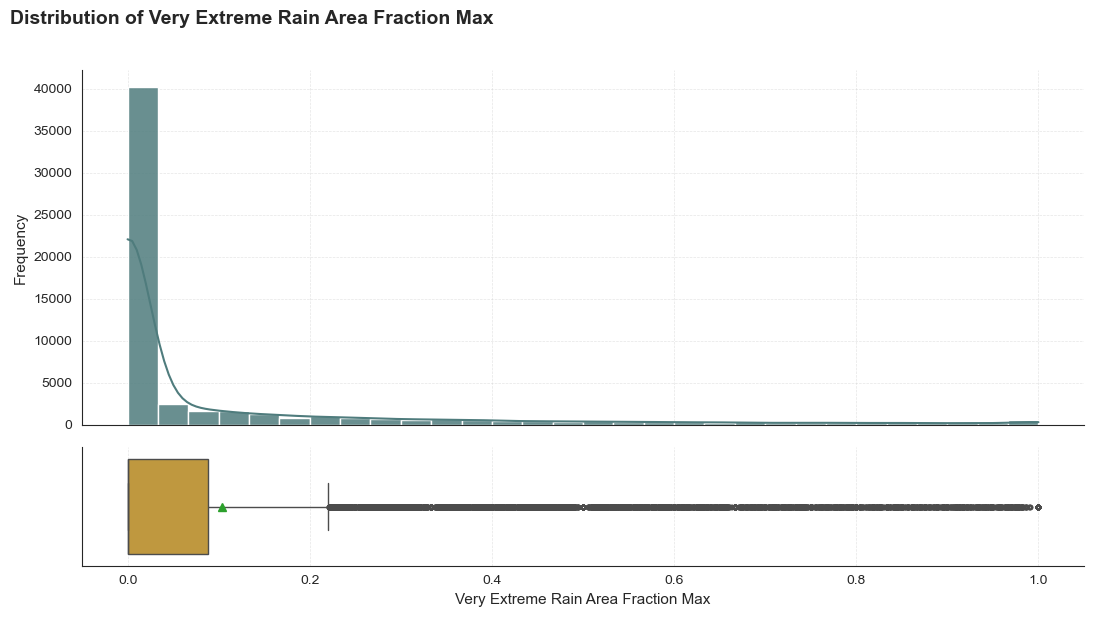

'DAYS_EXTREME_HEAT': 0 missing (0.0%), 4760 zeros (8.1%)
Skew: 0.800


,count,mean,std,min,25%,50%,75%,max
DAYS_EXTREME_HEAT,58512.0,7.90496,5.982188,0.0,3.0,7.0,12.0,31.0


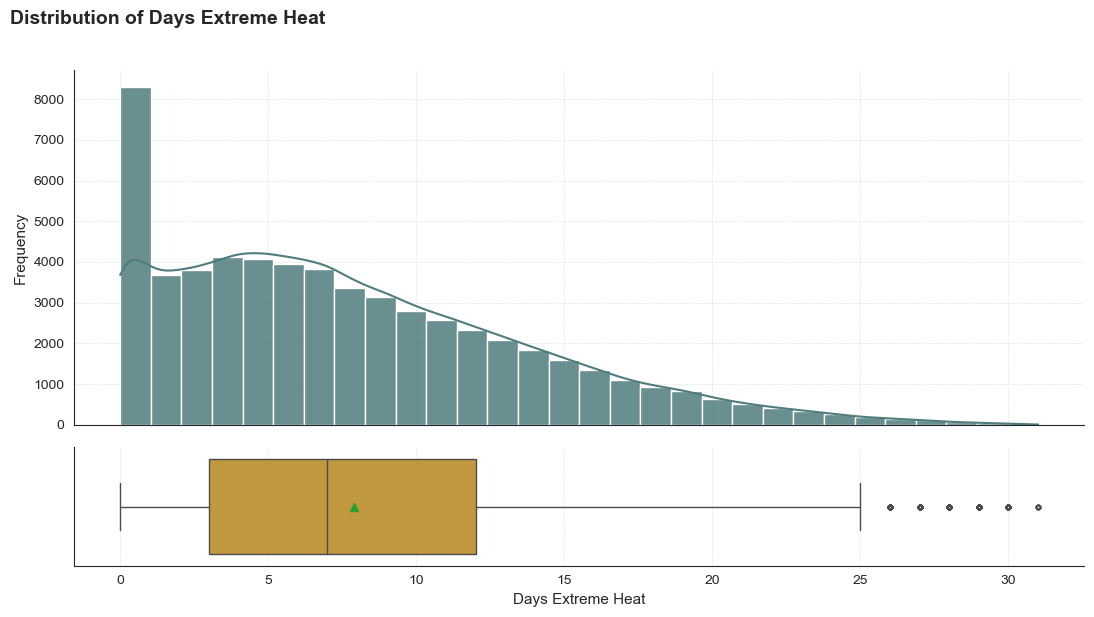

'DAYS_VERY_EXTREME_HEAT': 0 missing (0.0%), 11725 zeros (20.0%)
Skew: 1.349


,count,mean,std,min,25%,50%,75%,max
DAYS_VERY_EXTREME_HEAT,58512.0,4.616164,4.630949,0.0,1.0,3.0,7.0,30.0


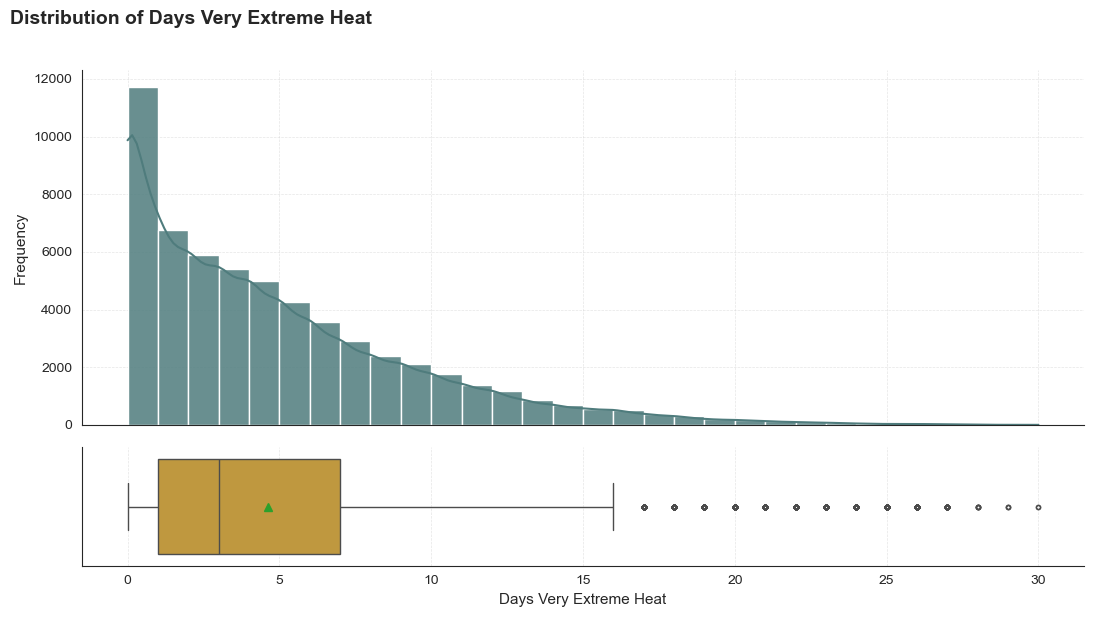

'EXTREME_HEAT_AREA_FRACTION_AVG': 0 missing (0.0%), 2971 zeros (5.1%)
Skew: 1.355


,count,mean,std,min,25%,50%,75%,max
EXTREME_HEAT_AREA_FRACTION_AVG,58512.0,0.127476,0.113867,0.0,0.040428,0.099798,0.182796,0.790323


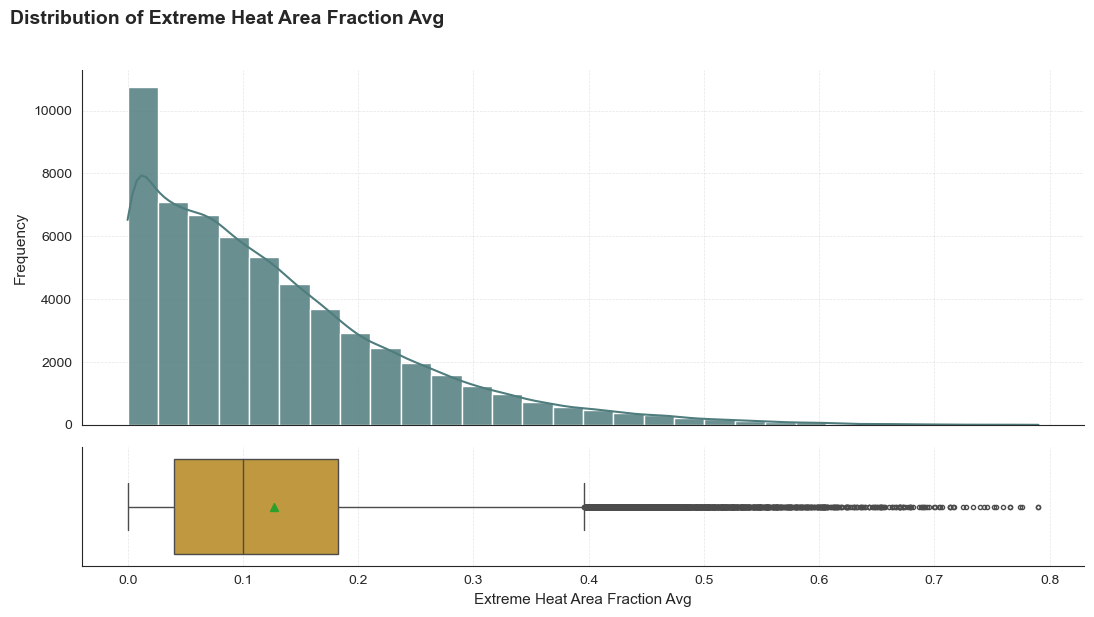

'EXTREME_HEAT_AREA_FRACTION_MAX': 0 missing (0.0%), 2971 zeros (5.1%)
Skew: -0.629


,count,mean,std,min,25%,50%,75%,max
EXTREME_HEAT_AREA_FRACTION_MAX,58512.0,0.645255,0.308186,0.0,0.4375,0.710843,0.923077,1.0


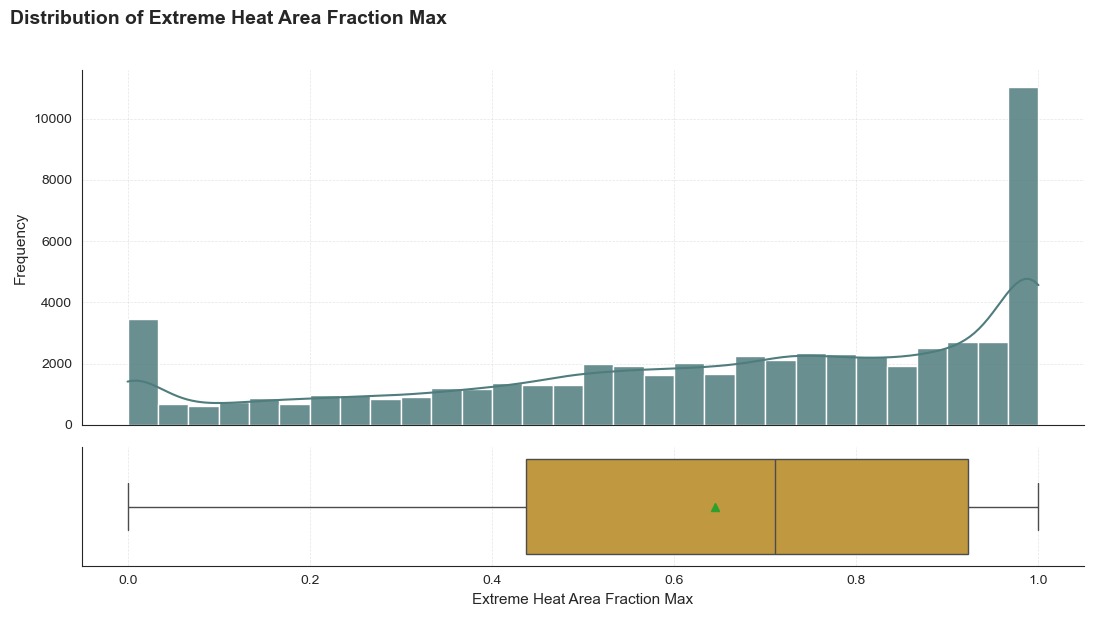

'EXTREME_HEAT_AREA_WHEN_PRESENT': 0 missing (0.0%), 2971 zeros (5.1%)
Skew: 0.371


,count,mean,std,min,25%,50%,75%,max
EXTREME_HEAT_AREA_WHEN_PRESENT,58512.0,0.339538,0.199034,0.0,0.192308,0.327083,0.471429,1.0


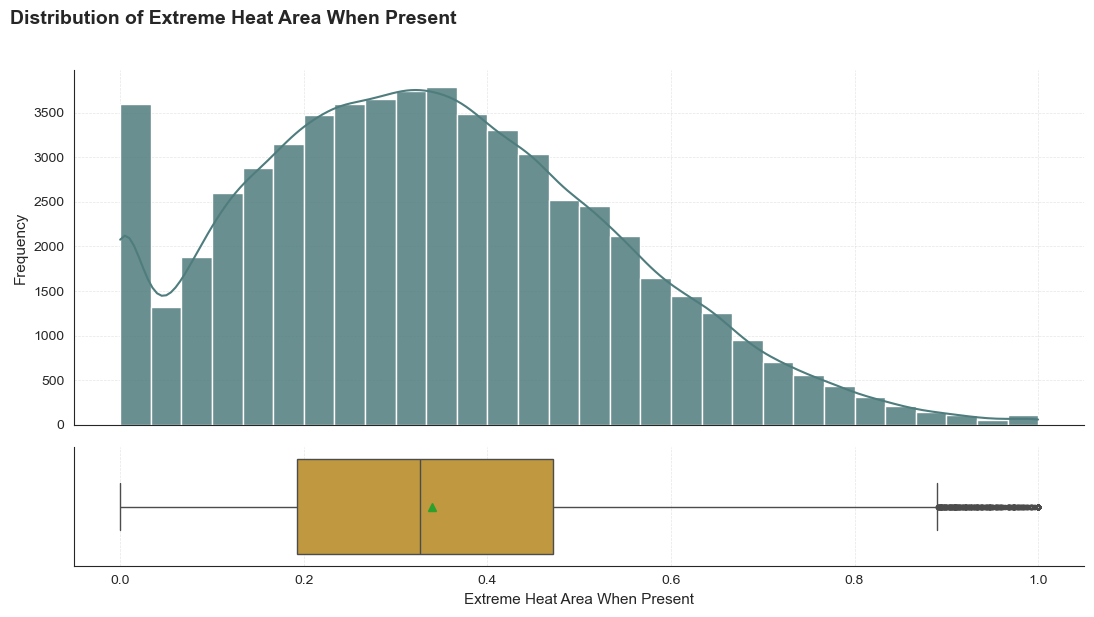

'DAYS_EXTREME_COLD': 0 missing (0.0%), 6838 zeros (11.7%)
Skew: 0.958


,count,mean,std,min,25%,50%,75%,max
DAYS_EXTREME_COLD,58512.0,6.5914,5.508327,0.0,2.0,5.0,10.0,31.0


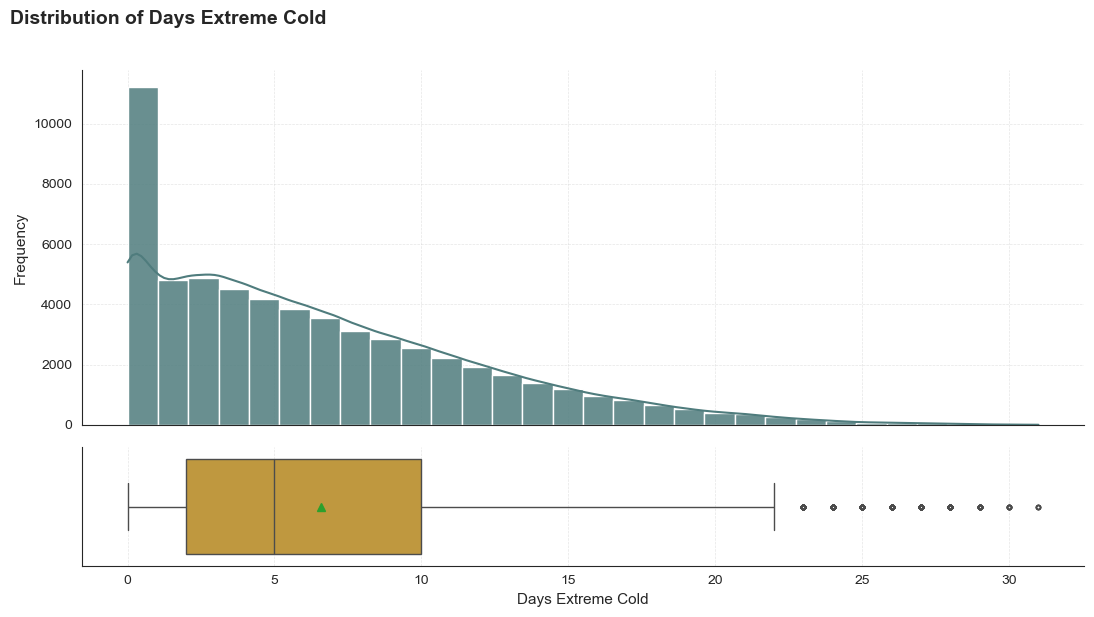

'EXTREME_COLD_AREA_FRACTION_AVG': 0 missing (0.0%), 2437 zeros (4.2%)
Skew: 1.582


,count,mean,std,min,25%,50%,75%,max
EXTREME_COLD_AREA_FRACTION_AVG,58512.0,0.084604,0.079139,0.0,0.02509,0.063689,0.120833,0.660282


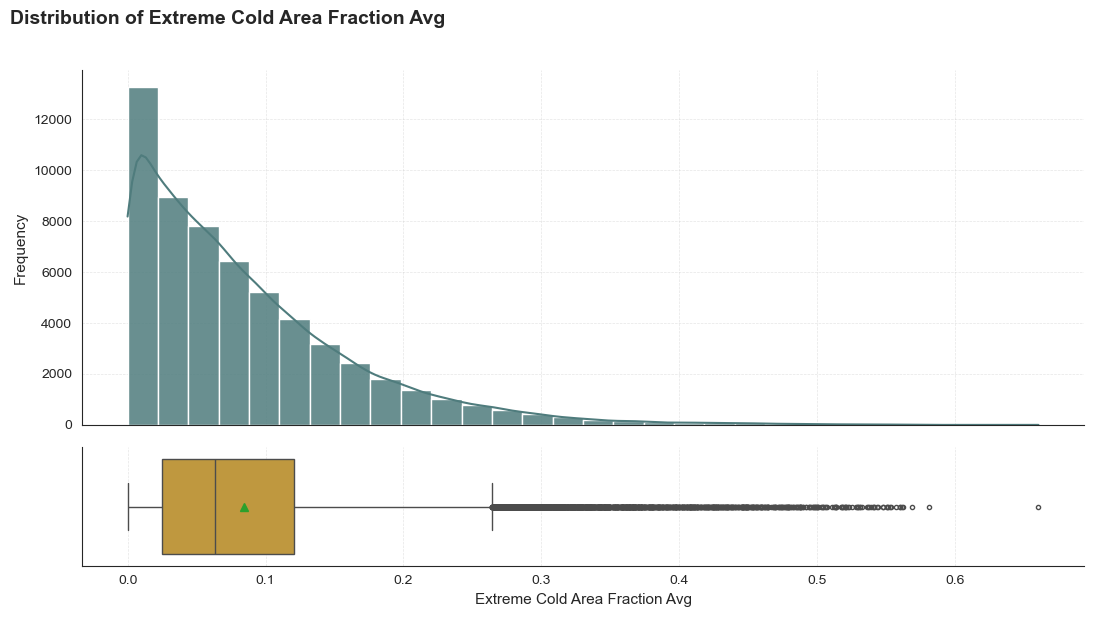

'EXTREME_COLD_AREA_FRACTION_MAX': 0 missing (0.0%), 2437 zeros (4.2%)
Skew: 0.141


,count,mean,std,min,25%,50%,75%,max
EXTREME_COLD_AREA_FRACTION_MAX,58512.0,0.50753,0.327378,0.0,0.225806,0.466667,0.815789,1.0


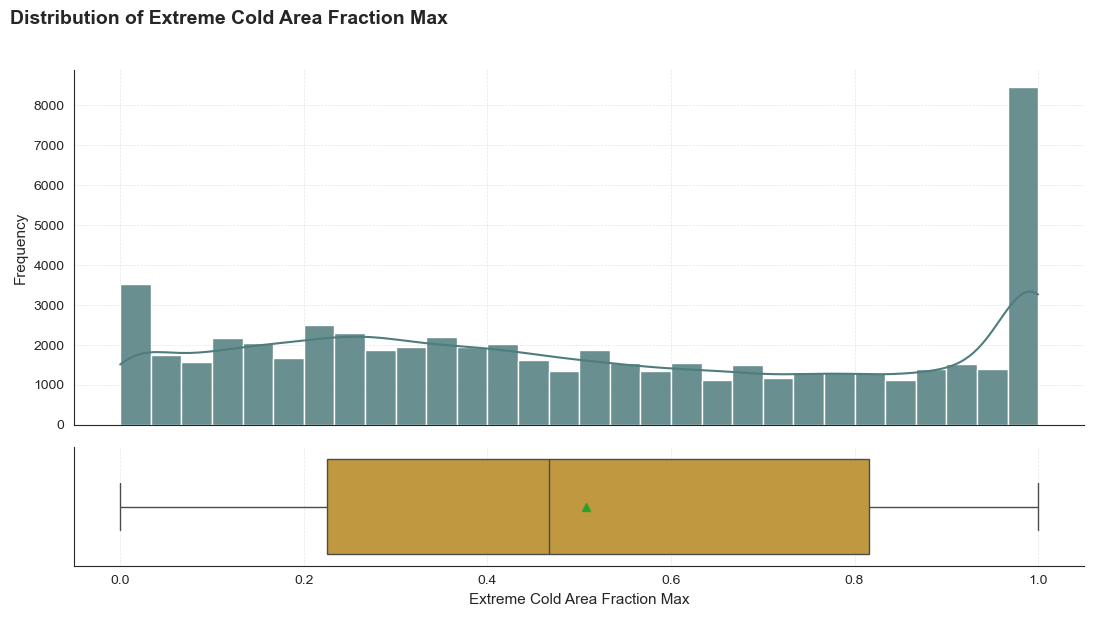

'EXTREME_COLD_AREA_WHEN_PRESENT': 0 missing (0.0%), 2437 zeros (4.2%)
Skew: 1.349


,count,mean,std,min,25%,50%,75%,max
EXTREME_COLD_AREA_WHEN_PRESENT,58512.0,0.209677,0.163475,0.0,0.092058,0.167702,0.2875,1.0


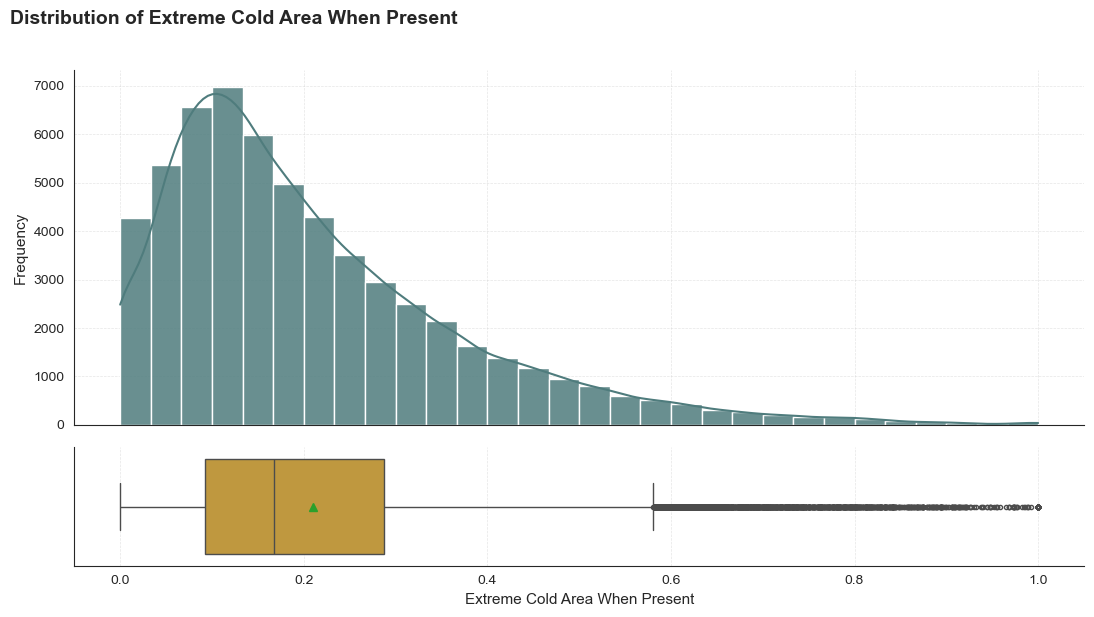

'DAYS_EXTREME_WIND': 0 missing (0.0%), 8822 zeros (15.1%)
Skew: 1.570


,count,mean,std,min,25%,50%,75%,max
DAYS_EXTREME_WIND,58512.0,3.584102,3.299144,0.0,1.0,3.0,5.0,30.0


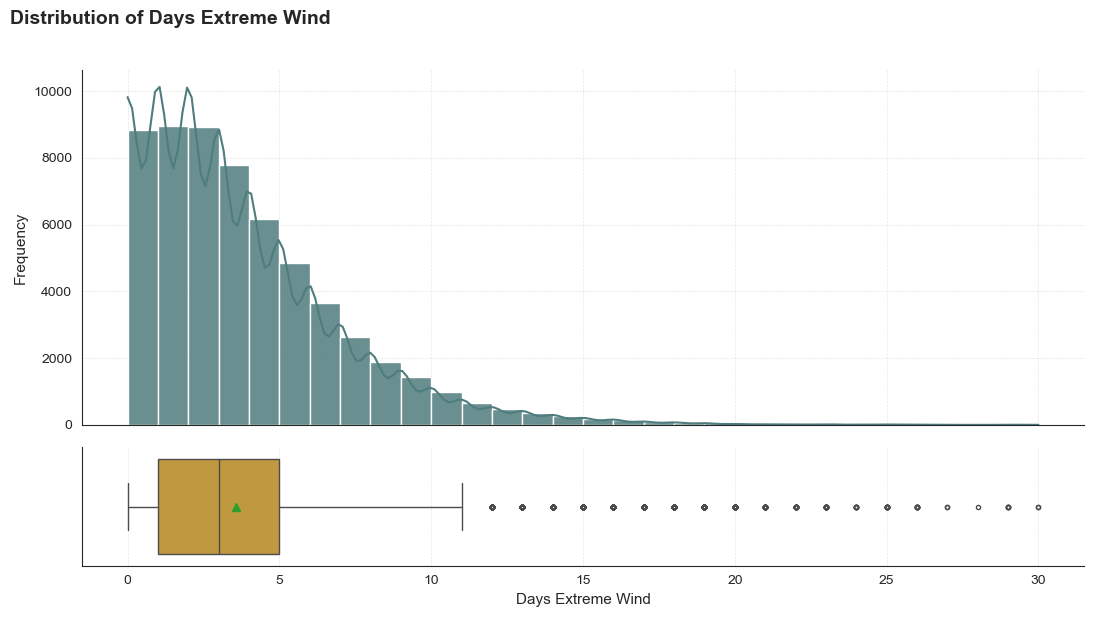

'EXTREME_WIND_AREA_FRACTION_AVG': 0 missing (0.0%), 3323 zeros (5.7%)
Skew: 1.492


,count,mean,std,min,25%,50%,75%,max
EXTREME_WIND_AREA_FRACTION_AVG,58512.0,0.045285,0.040493,0.0,0.014516,0.035654,0.065136,0.412298


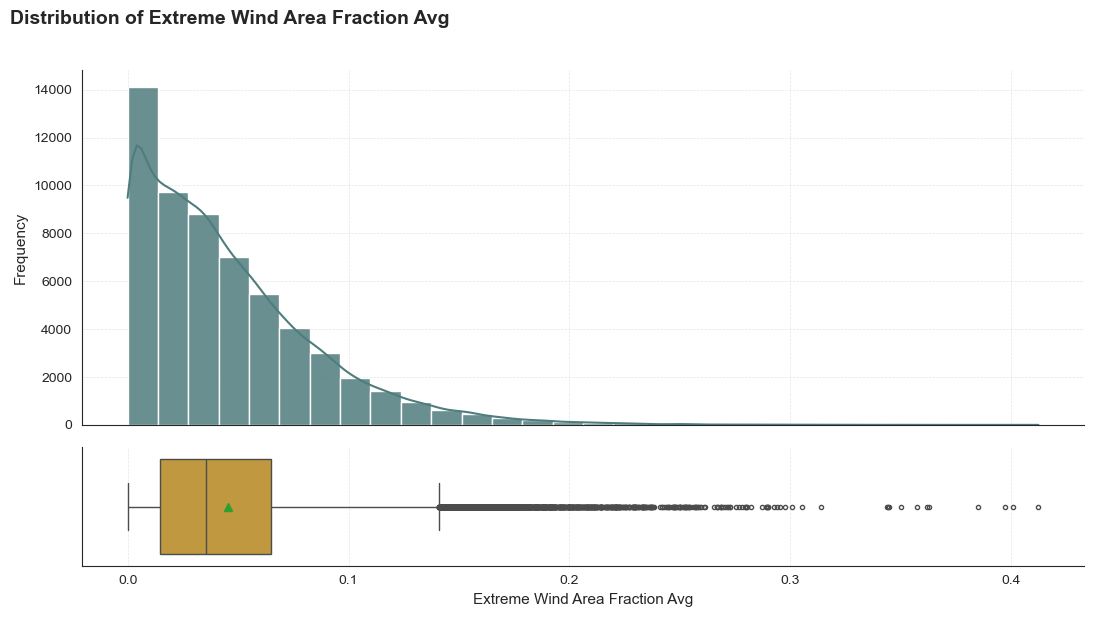

'EXTREME_WIND_AREA_FRACTION_MAX': 0 missing (0.0%), 3323 zeros (5.7%)
Skew: 0.290


,count,mean,std,min,25%,50%,75%,max
EXTREME_WIND_AREA_FRACTION_MAX,58512.0,0.460109,0.323174,0.0,0.179487,0.407407,0.73913,1.0


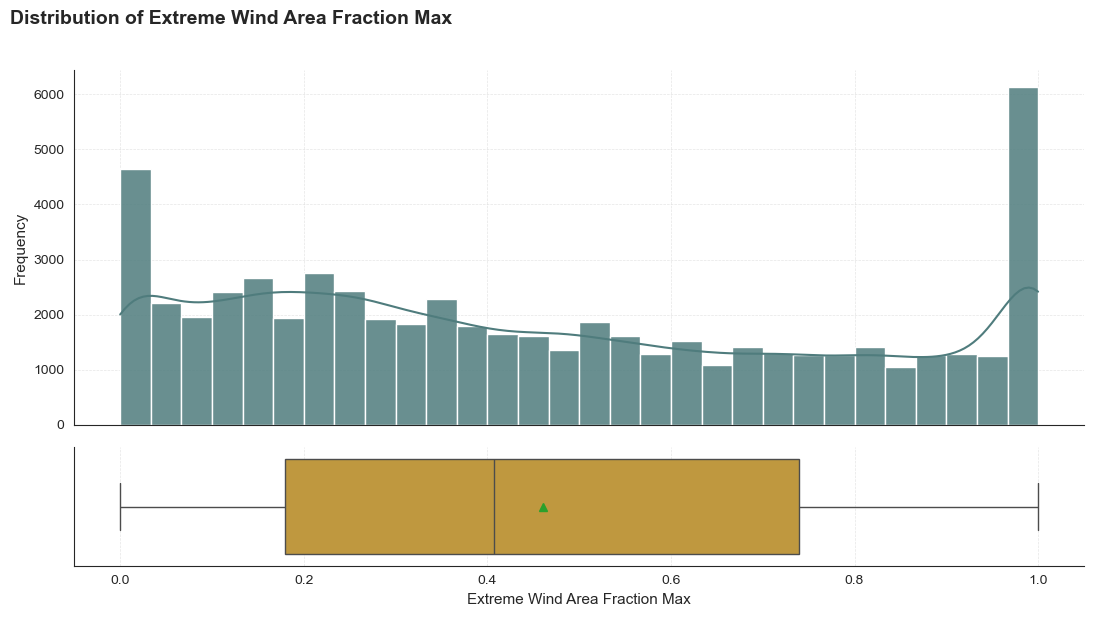

'EXTREME_WIND_AREA_WHEN_PRESENT': 0 missing (0.0%), 3323 zeros (5.7%)
Skew: 1.324


,count,mean,std,min,25%,50%,75%,max
EXTREME_WIND_AREA_WHEN_PRESENT,58512.0,0.225815,0.186981,0.0,0.088542,0.177143,0.316527,1.0


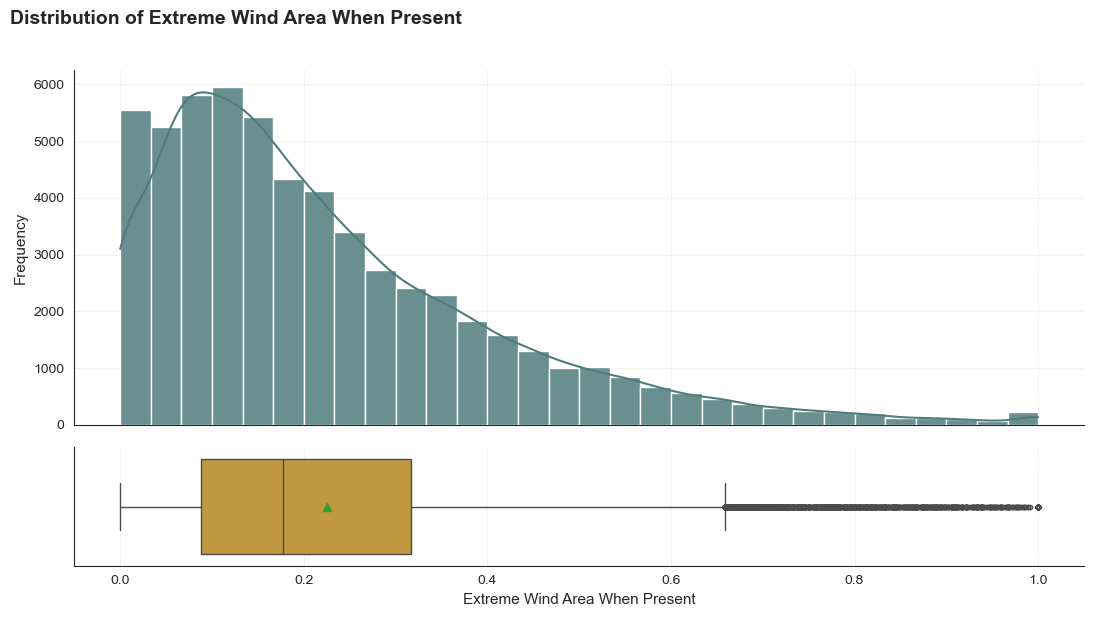

'DAYS_FROST_ANY_AREA': 0 missing (0.0%), 28359 zeros (48.5%)
Skew: 1.012


,count,mean,std,min,25%,50%,75%,max
DAYS_FROST_ANY_AREA,58512.0,8.049323,10.736999,0.0,0.0,1.0,16.0,31.0


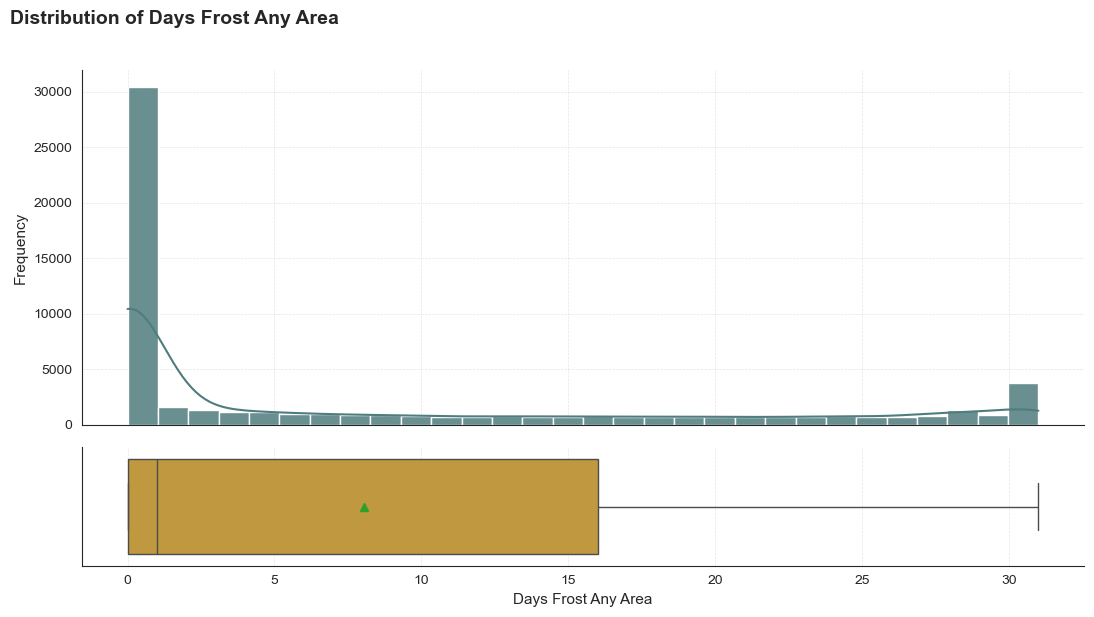

'DAYS_FROST_10PCT': 0 missing (0.0%), 32777 zeros (56.0%)
Skew: 1.445


,count,mean,std,min,25%,50%,75%,max
DAYS_FROST_10PCT,58512.0,6.049084,9.533724,0.0,0.0,0.0,10.0,31.0


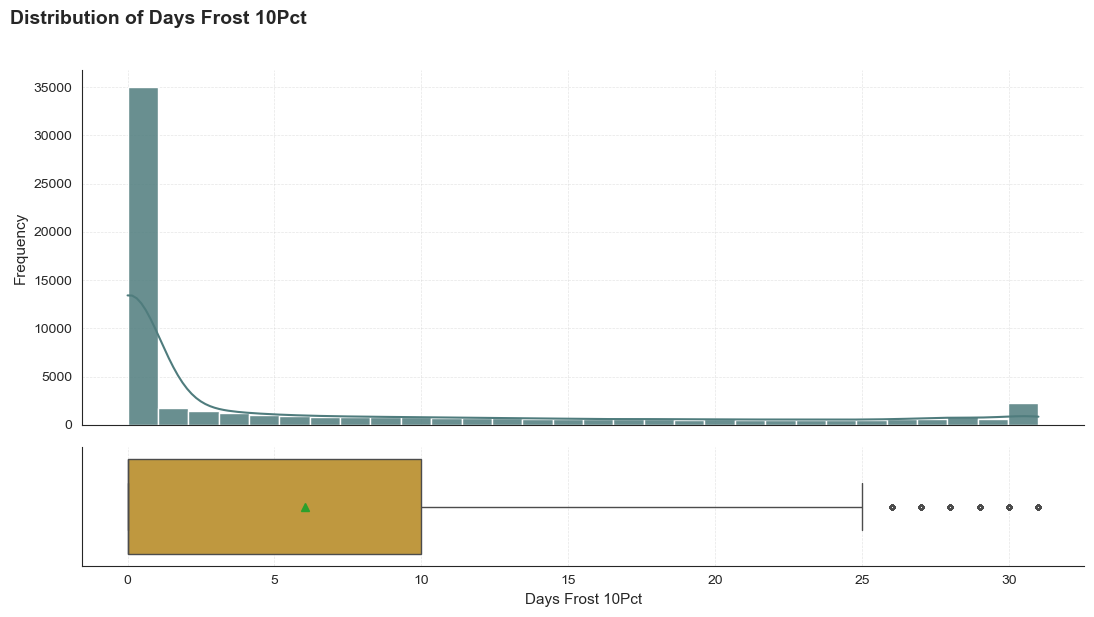

'DAYS_HOT_30_ANY_AREA': 0 missing (0.0%), 36195 zeros (61.9%)
Skew: 1.567


,count,mean,std,min,25%,50%,75%,max
DAYS_HOT_30_ANY_AREA,58512.0,5.432304,9.212114,0.0,0.0,0.0,8.0,31.0


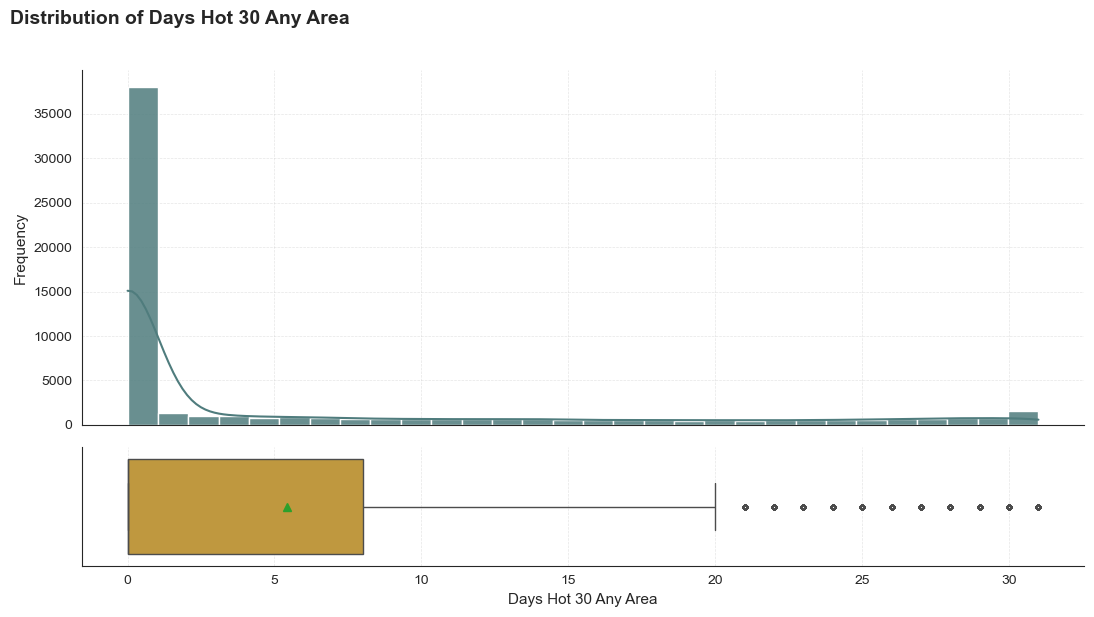

'DAYS_HOT_30_10PCT': 0 missing (0.0%), 37974 zeros (64.9%)
Skew: 1.786


,count,mean,std,min,25%,50%,75%,max
DAYS_HOT_30_10PCT,58512.0,4.618711,8.409849,0.0,0.0,0.0,5.0,31.0


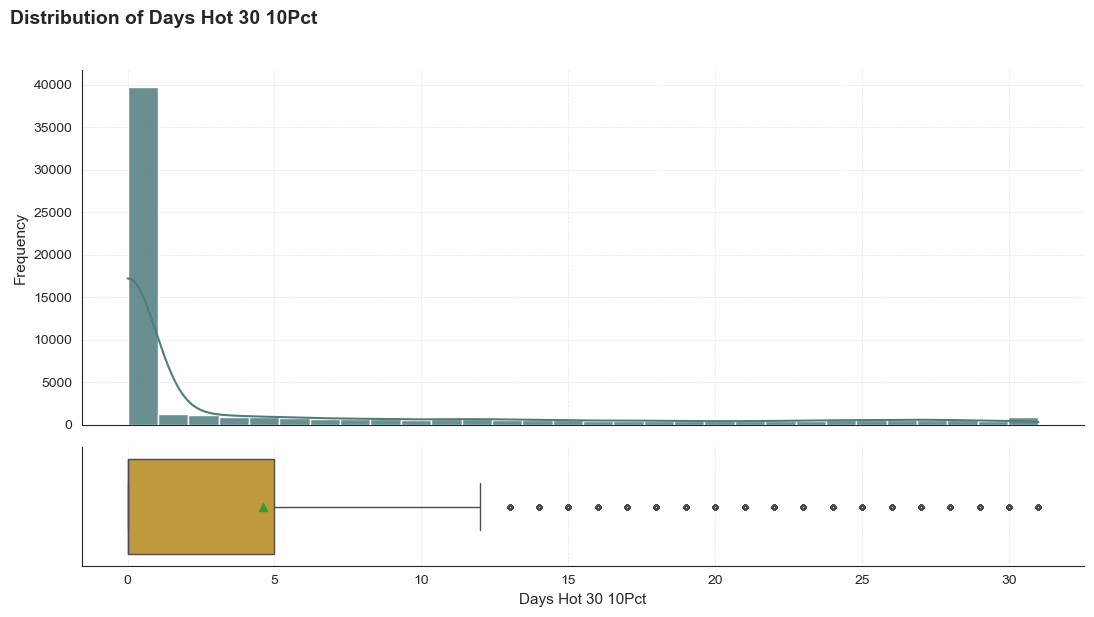

'DAYS_HOT_35_ANY_AREA': 0 missing (0.0%), 48187 zeros (82.4%)
Skew: 4.065


,count,mean,std,min,25%,50%,75%,max
DAYS_HOT_35_ANY_AREA,58512.0,1.146551,3.502974,0.0,0.0,0.0,0.0,30.0


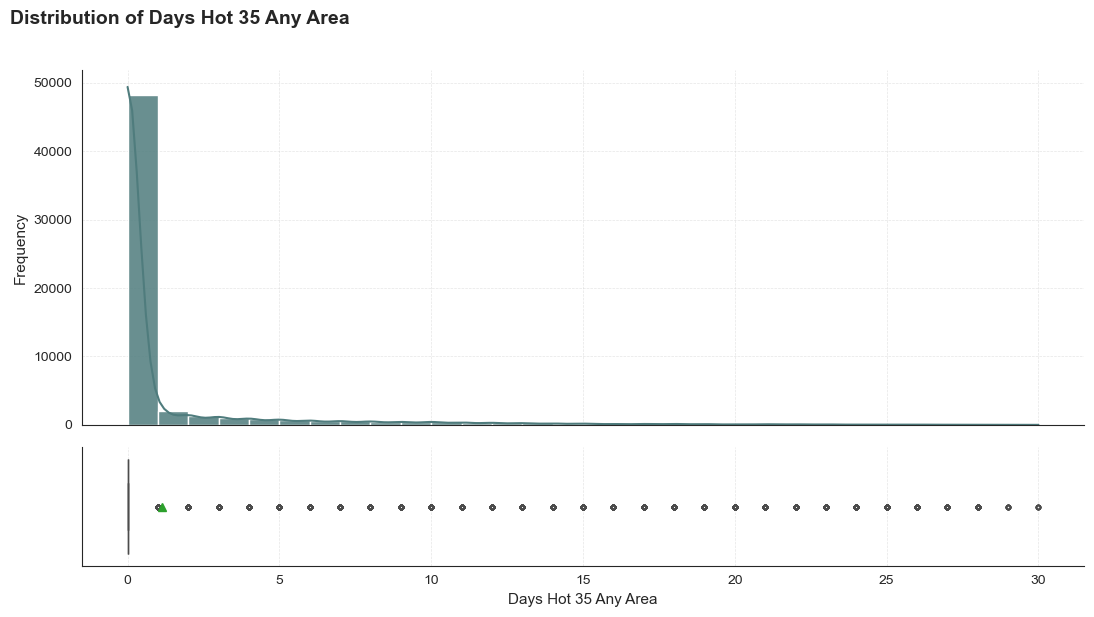

'DAYS_HOT_35_10PCT': 0 missing (0.0%), 50311 zeros (86.0%)


,Days Hot 35 10Pct,abs_freq,rel_freq_%
0,0,50311,85.98
1,1,1810,3.09
2,2,1210,2.07
3,3,955,1.63
4,4,687,1.17
5,5,580,0.99
6,6,441,0.75
7,7,436,0.75
8,8,363,0.62
9,9,344,0.59


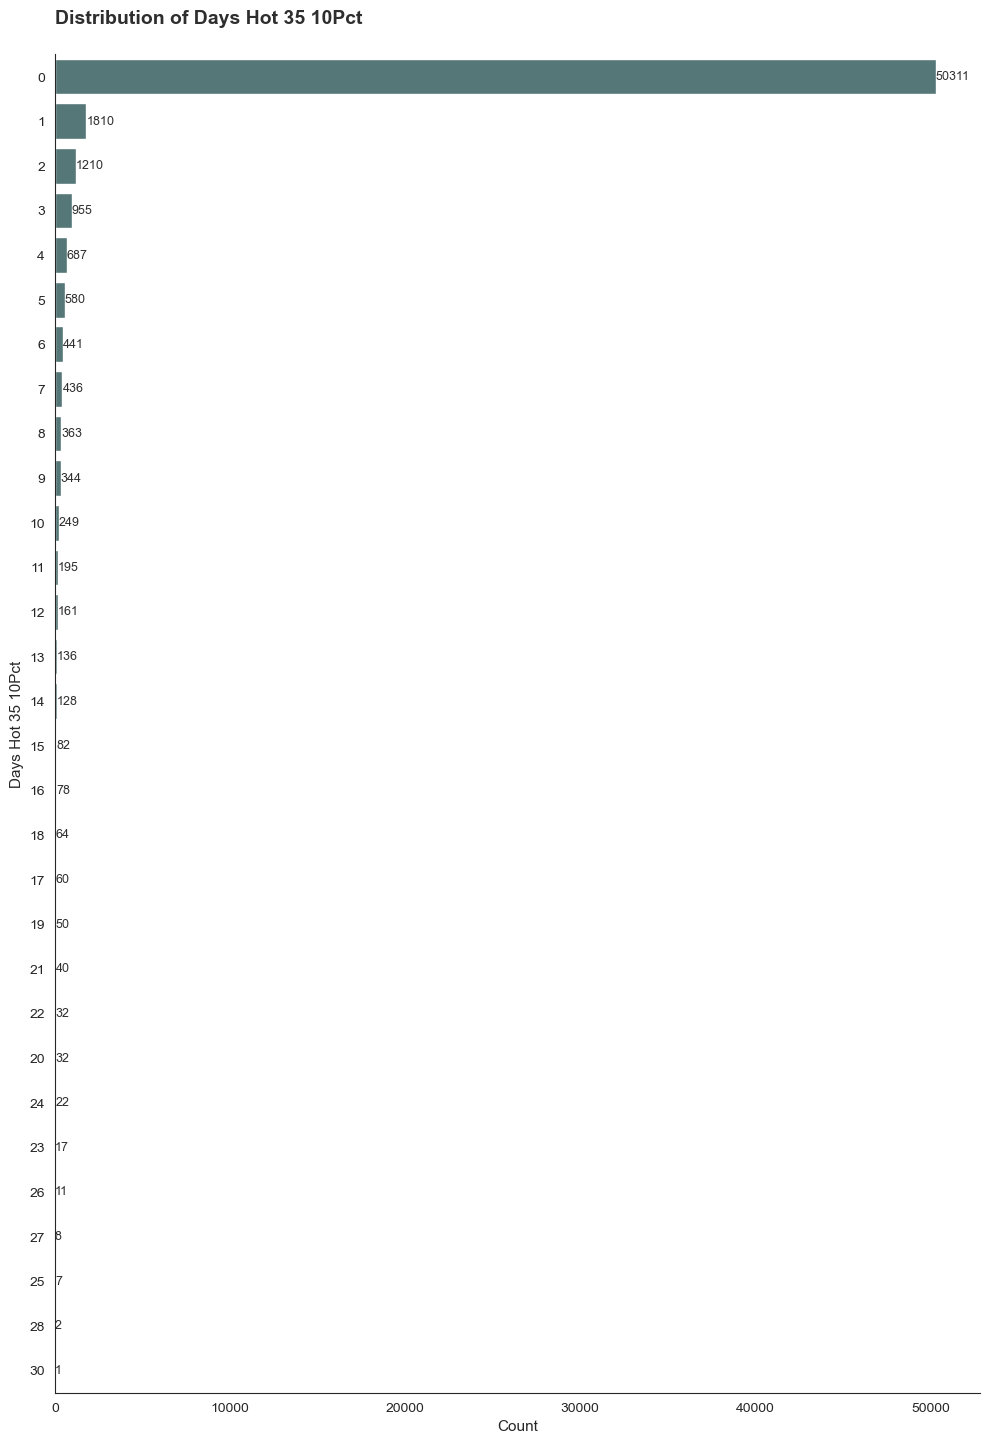

'MAX_CONSECUTIVE_EXTREME_HEAT_DAYS': 0 missing (0.0%), 4760 zeros (8.1%)
Skew: 1.602


,count,mean,std,min,25%,50%,75%,max
MAX_CONSECUTIVE_EXTREME_HEAT_DAYS,58512.0,4.598373,3.890267,0.0,2.0,4.0,6.0,31.0


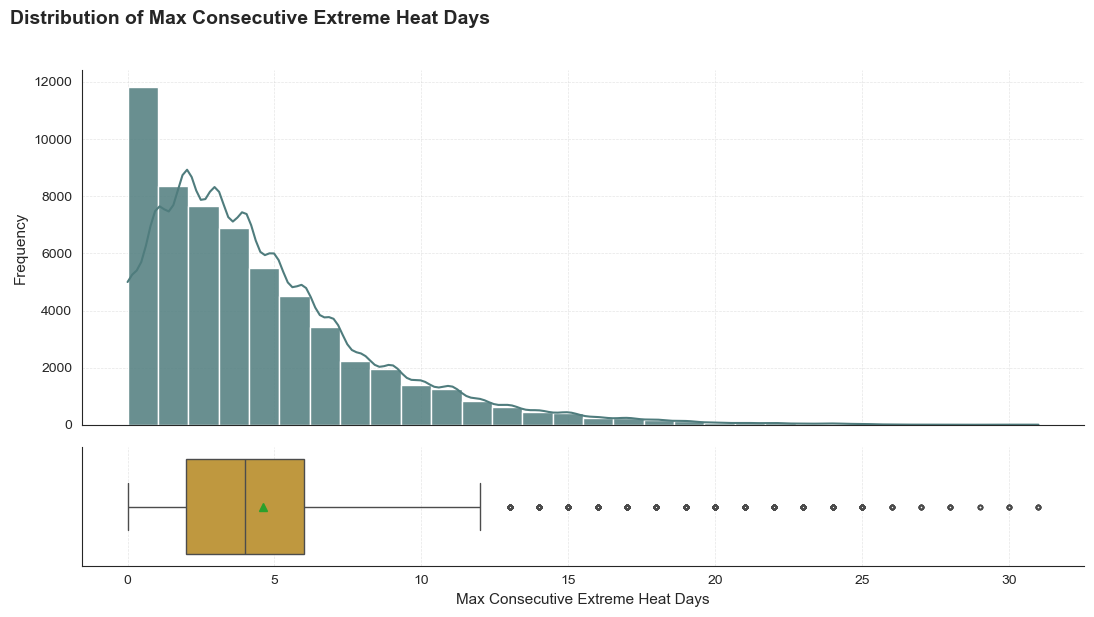

'MAX_CONSECUTIVE_VERY_EXTREME_HEAT_DAYS': 0 missing (0.0%), 11725 zeros (20.0%)


,Max Consecutive Very Extreme Heat Days,abs_freq,rel_freq_%
0,0,11725,20.04
1,1,11560,19.76
2,2,9838,16.81
3,3,7506,12.83
4,4,5462,9.33
5,5,3783,6.47
6,6,2729,4.66
7,7,1739,2.97
8,8,1087,1.86
9,9,833,1.42


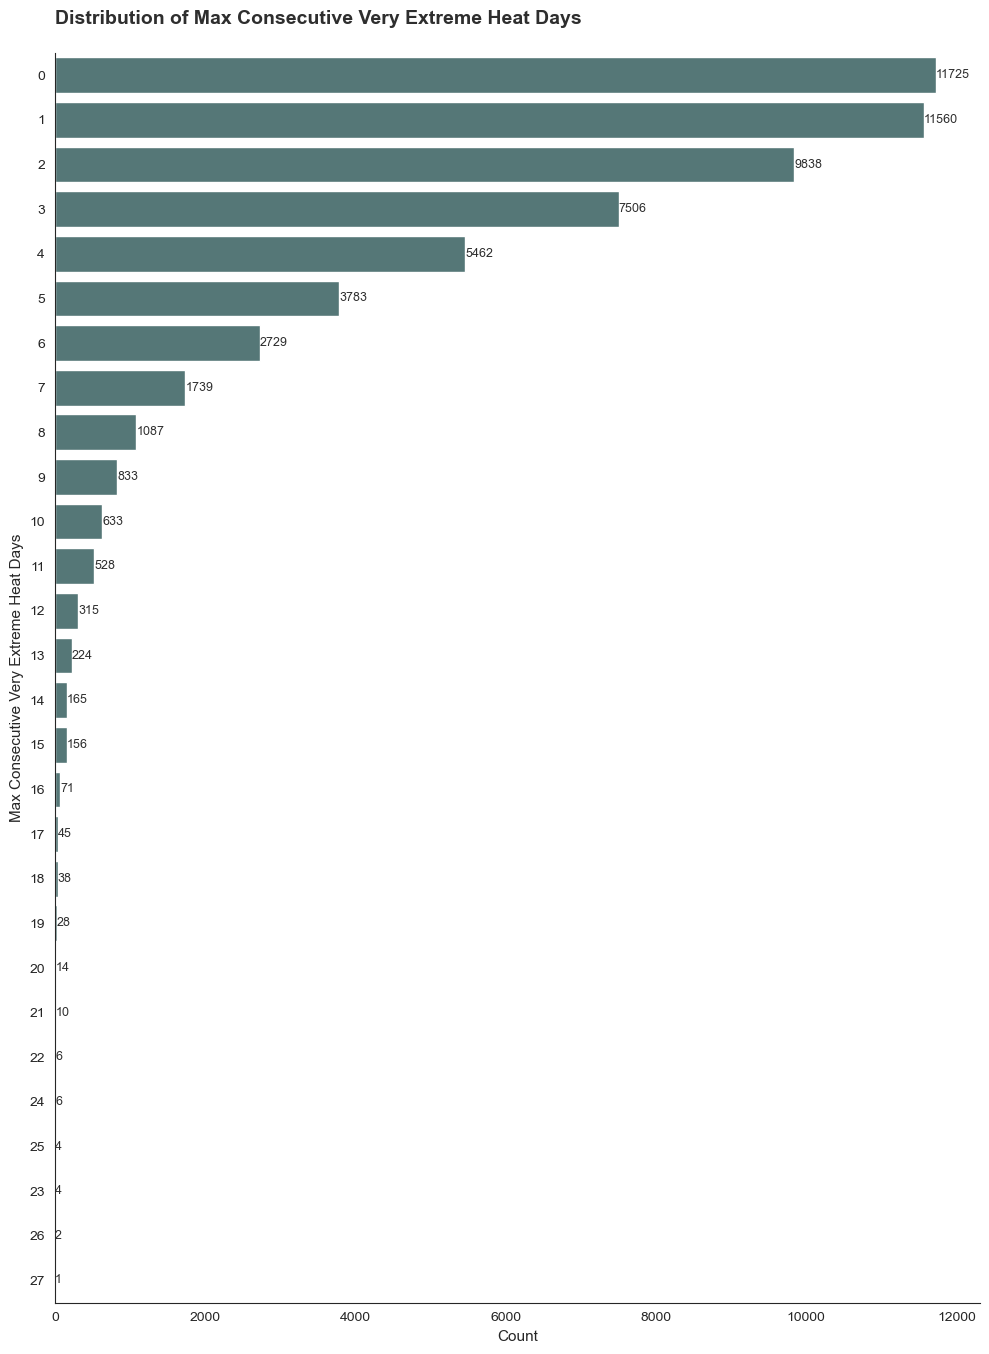

'MAX_CONSECUTIVE_EXTREME_COLD_DAYS': 0 missing (0.0%), 6838 zeros (11.7%)
Skew: 1.703


,count,mean,std,min,25%,50%,75%,max
MAX_CONSECUTIVE_EXTREME_COLD_DAYS,58512.0,3.840255,3.377397,0.0,2.0,3.0,5.0,31.0


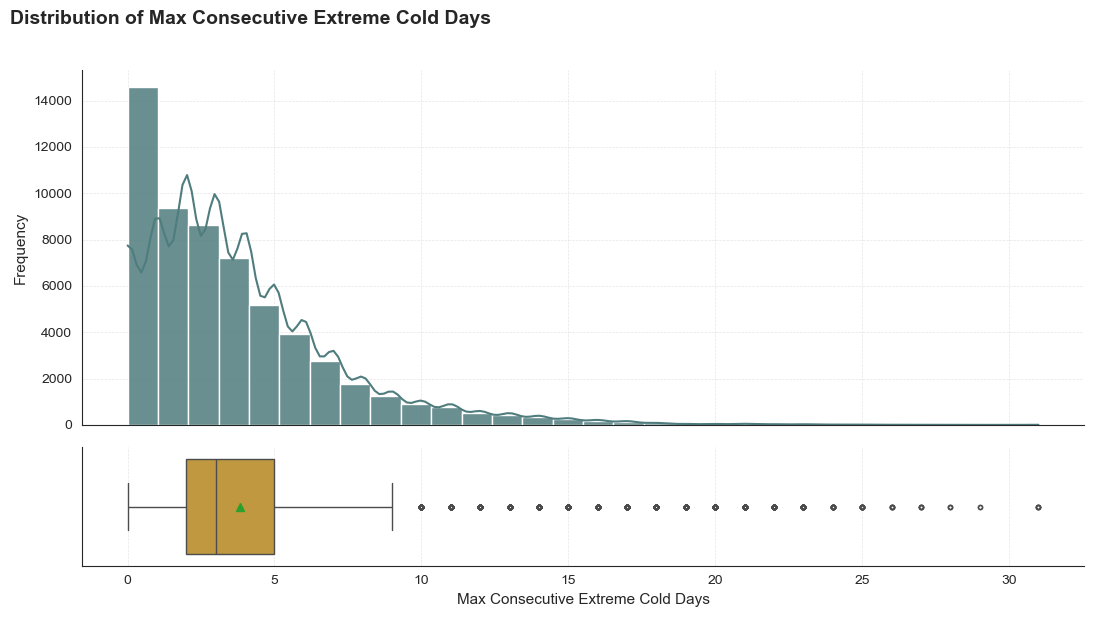

'MAX_CONSECUTIVE_EXTREME_RAIN_DAYS': 0 missing (0.0%), 24626 zeros (42.1%)


,Max Consecutive Extreme Rain Days,abs_freq,rel_freq_%
1,0,24626,42.09
0,1,24985,42.70
2,2,7352,12.56
3,3,1338,2.29
4,4,179,0.31
5,5,29,0.05
6,6,3,0.01


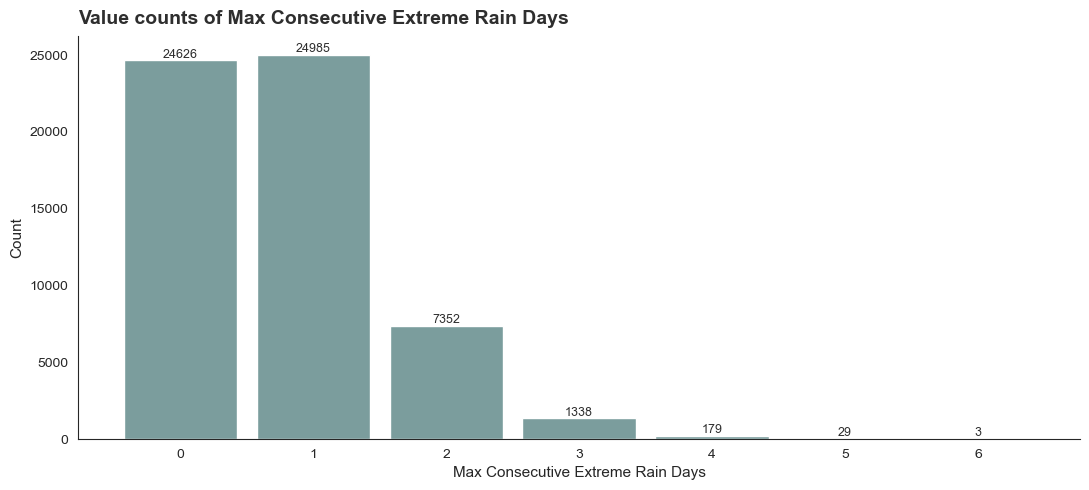

'MAX_CONSECUTIVE_VERY_EXTREME_RAIN_DAYS': 0 missing (0.0%), 44487 zeros (76.0%)


,Max Consecutive Very Extreme Rain Days,abs_freq,rel_freq_%
0,0,44487,76.03
1,1,12447,21.27
2,2,1432,2.45
3,3,139,0.24
4,4,7,0.01


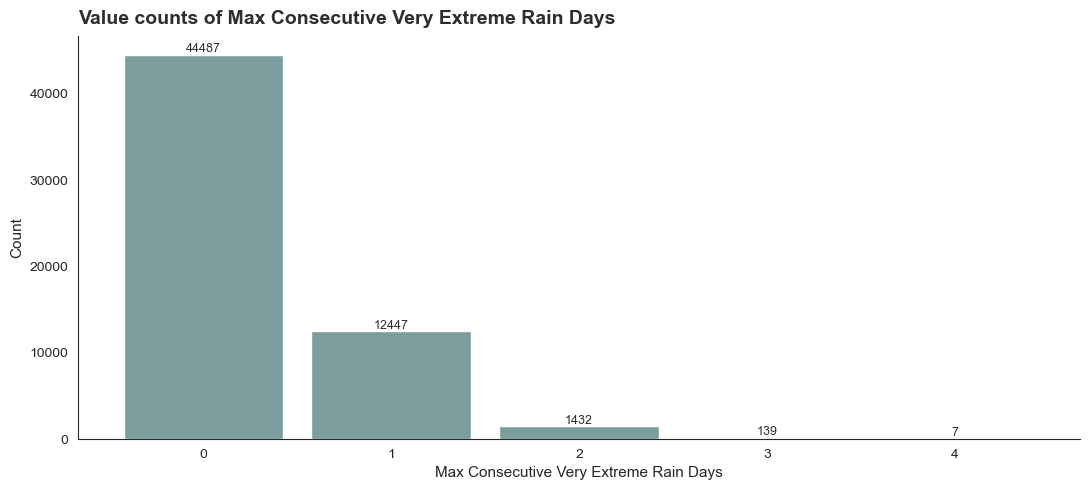

'MAX_CONSECUTIVE_EXTREME_WIND_DAYS': 0 missing (0.0%), 8822 zeros (15.1%)


,Max Consecutive Extreme Wind Days,abs_freq,rel_freq_%
0,1,19039,32.54
1,2,16680,28.51
2,0,8822,15.08
3,3,8073,13.80
4,4,3471,5.93
5,5,1336,2.28
6,6,559,0.96
7,7,247,0.42
8,8,110,0.19
9,9,71,0.12


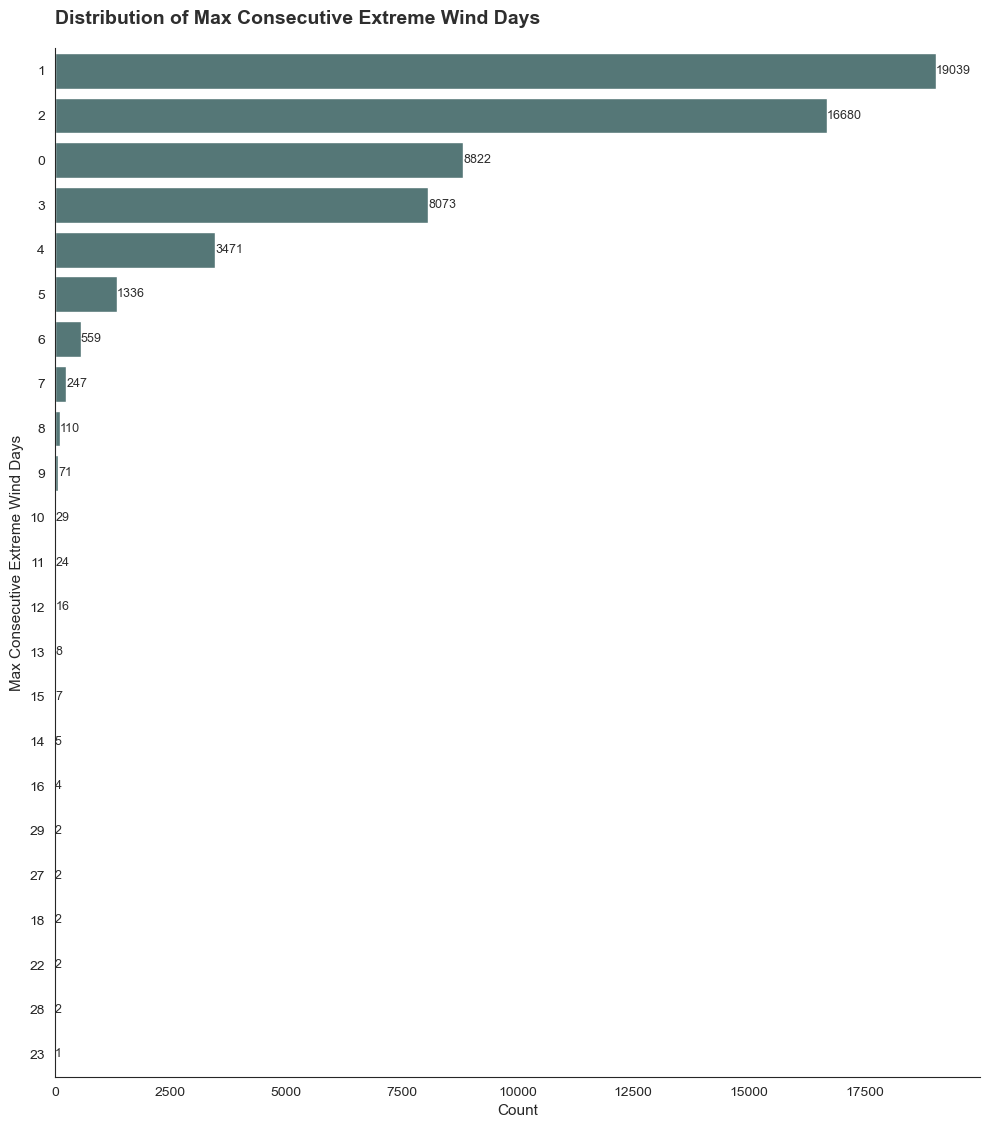

'MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN': 0 missing (0.0%), 1 zeros (0.0%)
Skew: 1.148


,count,mean,std,min,25%,50%,75%,max
MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN,58512.0,11.51169,6.203667,0.0,7.0,10.0,15.0,31.0


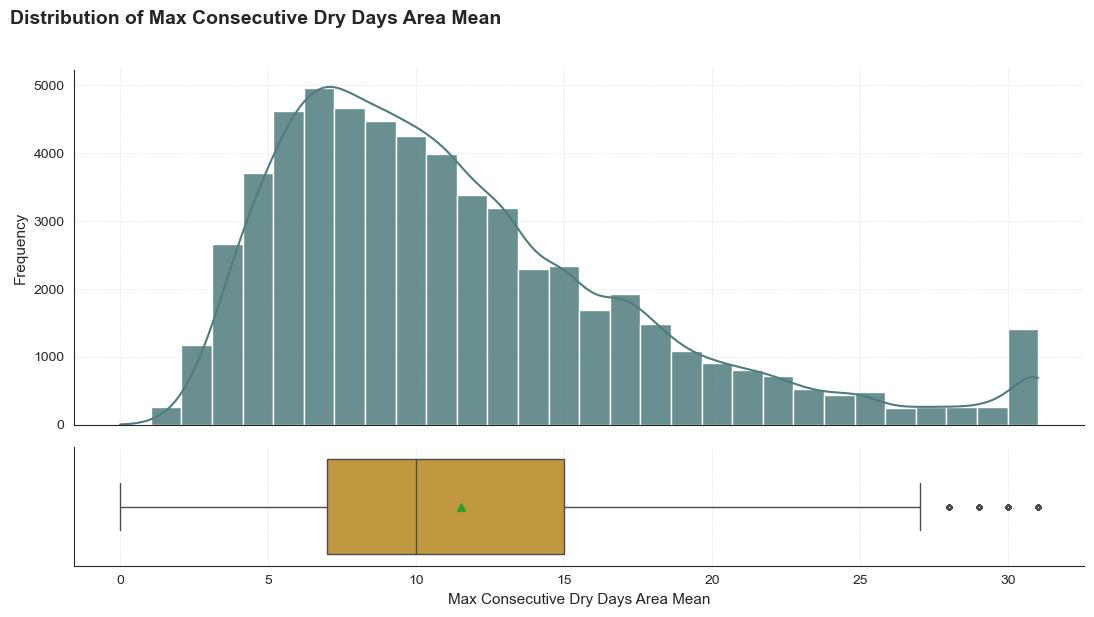

'MAX_CONSECUTIVE_WET_DAYS_AREA_MEAN': 0 missing (0.0%), 1354 zeros (2.3%)


,Max Consecutive Wet Days Area Mean,abs_freq,rel_freq_%
0,3,12143,20.75
1,2,11573,19.78
2,4,10433,17.83
3,5,6999,11.96
4,1,5150,8.80
5,6,4435,7.58
6,7,2503,4.28
7,8,1512,2.58
8,0,1354,2.31
9,9,975,1.67


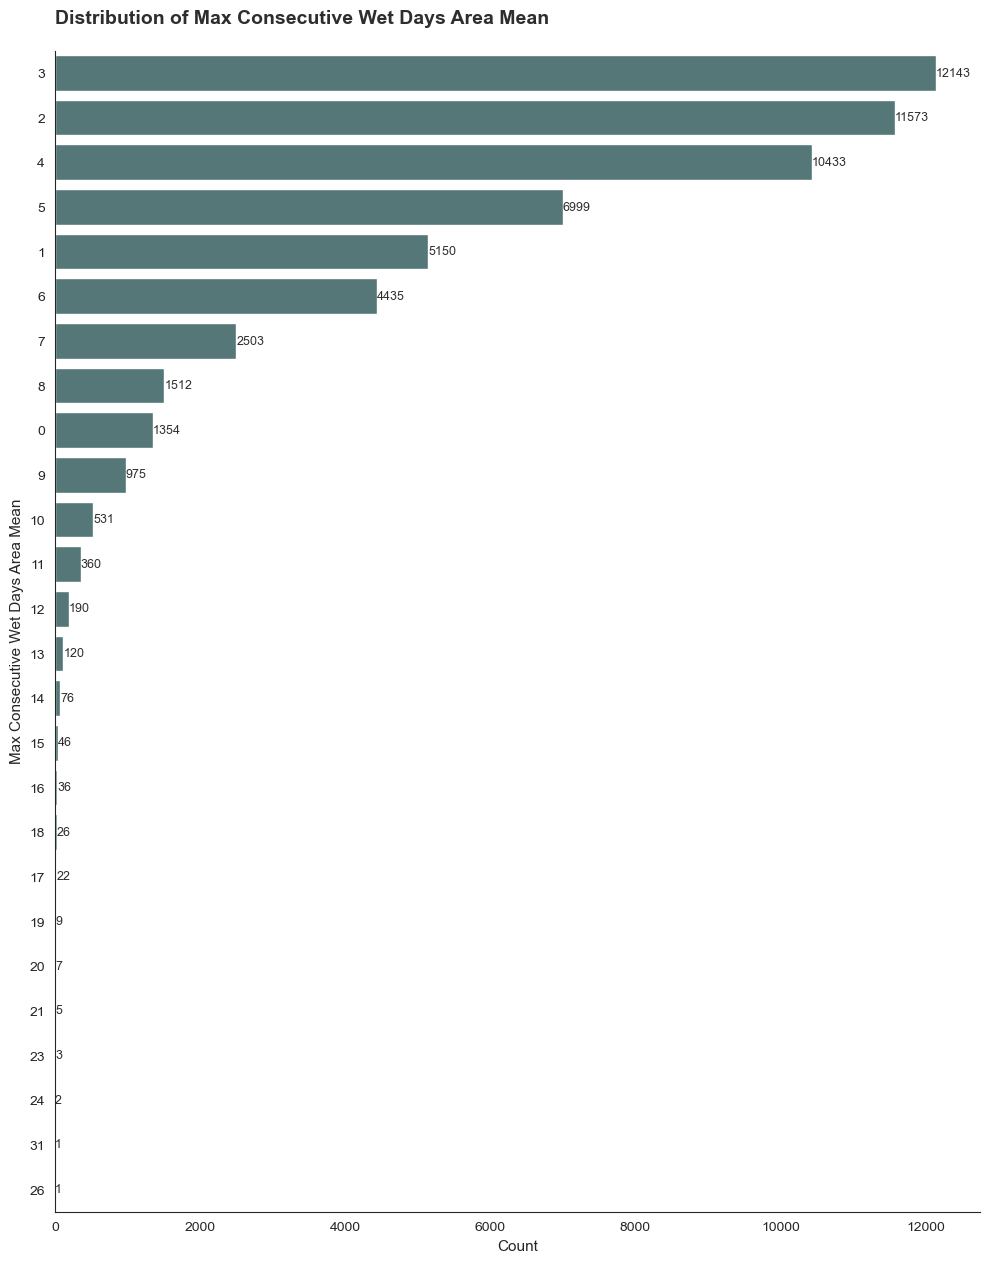

'MAX_CONSECUTIVE_FROST_10PCT_DAYS': 0 missing (0.0%), 32777 zeros (56.0%)
Skew: 2.159


,count,mean,std,min,25%,50%,75%,max
MAX_CONSECUTIVE_FROST_10PCT_DAYS,58512.0,4.334649,7.877986,0.0,0.0,0.0,5.0,31.0


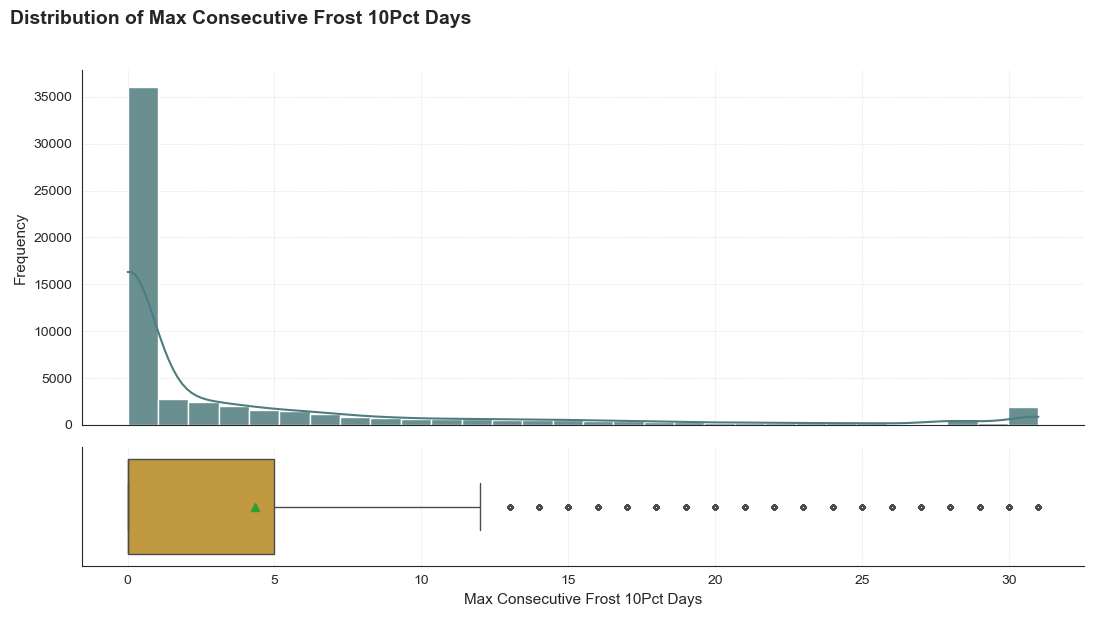

'MAX_CONSECUTIVE_HOT_30_10PCT_DAYS': 0 missing (0.0%), 37974 zeros (64.9%)
Skew: 2.501


,count,mean,std,min,25%,50%,75%,max
MAX_CONSECUTIVE_HOT_30_10PCT_DAYS,58512.0,3.02673,6.02468,0.0,0.0,0.0,3.0,31.0


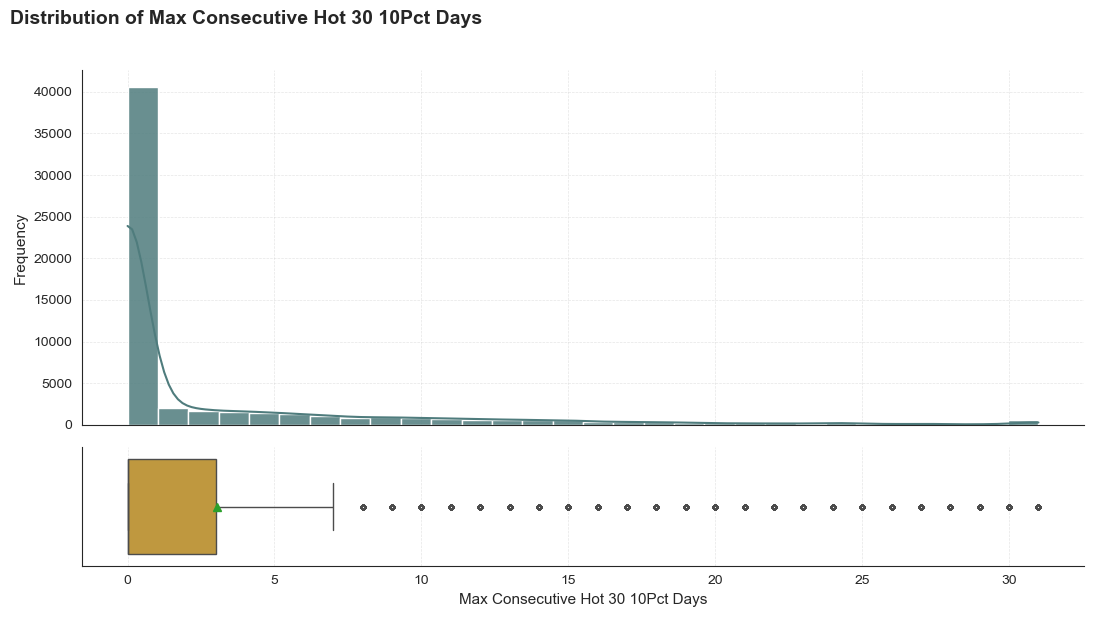

'MAX_CONSECUTIVE_HOT_35_10PCT_DAYS': 0 missing (0.0%), 50311 zeros (86.0%)


,Max Consecutive Hot 35 10Pct Days,abs_freq,rel_freq_%
0,0,50311,85.98
1,1,2489,4.25
2,2,1594,2.72
3,3,1167,1.99
4,4,794,1.36
5,5,544,0.93
6,6,419,0.72
7,7,278,0.48
8,8,231,0.39
9,9,219,0.37


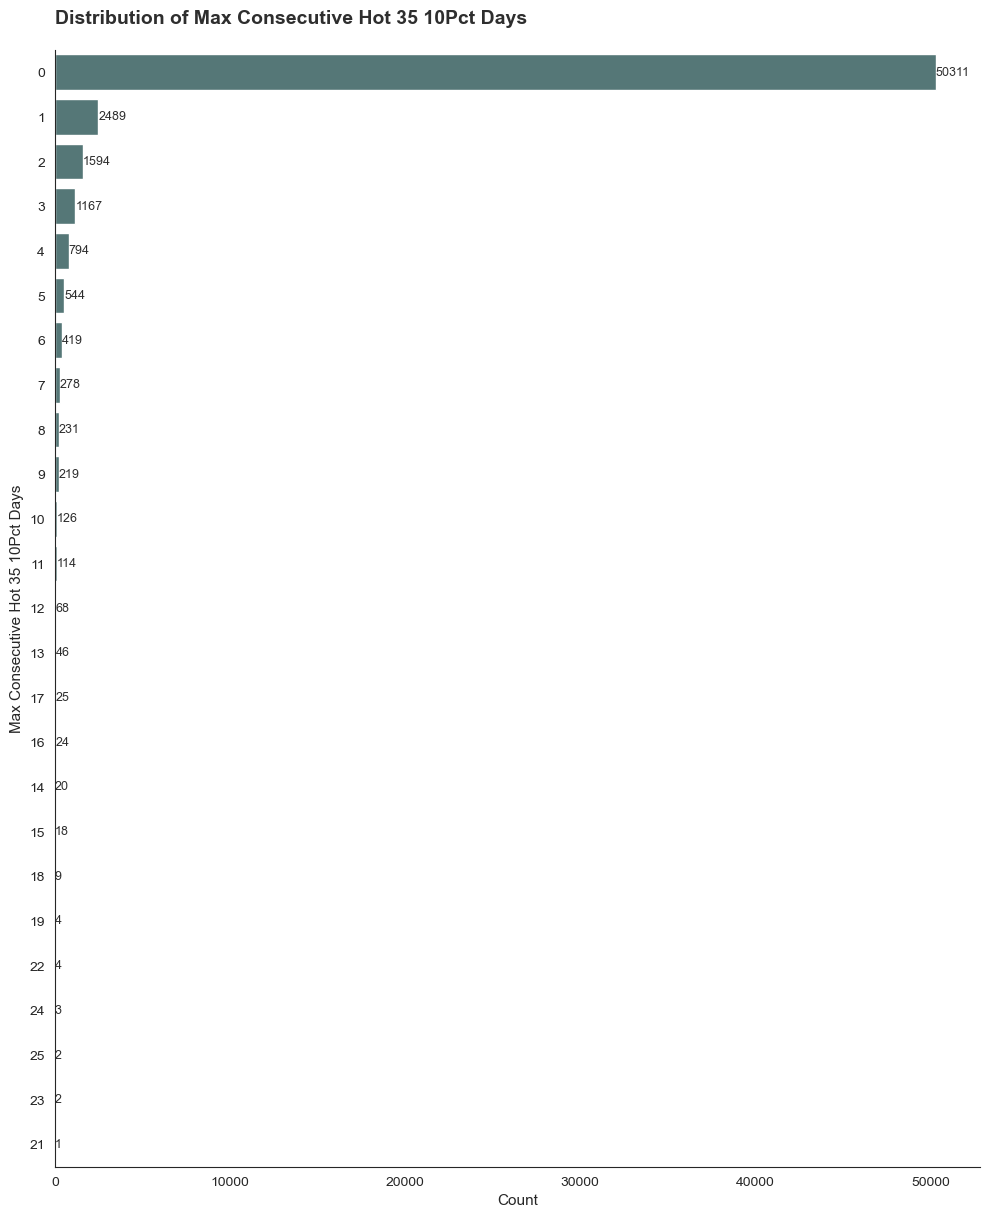

In [15]:
for c in climate_cols:
    kind = infer_variable_type(df[c])
    # It is necessary to turn off the aout_log attribute: there are many zero values which causes an error with log scaling
    # A continuos distribution is plotted only if there are enough unique values, otherwise it is more effective to 
    # treat it as a discrete distribution
    if kind == "continuous" and df[c].nunique() > 30:
        plot_numeric_distribution(df, c, auto_log = False)
    elif kind == "continuous" and df[c].nunique() <=  30 and df[c].nunique() > 7:
        plot_categorical_distribution(df, c, max_categories = 30, horizontal = True)
    elif kind == "continuous":
        plot_discrete_distribution(df, c)
    elif kind == "discrete":
        plot_discrete_distribution(df, c)
    else:
        plot_categorical_distribution(df, c)

**IMPORTANT OBSERVATIONS**

**1. Conditional intensity and the meaning of zeros**

The indicators describing extreme events follow a recurring structure made of three complementary quantities:

- a **count** of days on which the event occurred (`DAYS_EXTREME_*`);
- an **unconditional spatial average**, computed over all days of the month (`*_AREA_FRACTION_AVG`), which is zero when the event never occurs;
- a **conditional spatial average**, computed only on days on which the event occurred (`*_AREA_WHEN_PRESENT`).

The zeros in these variables  mean that the event did not take place. The three groups share the same zero mask - for extreme rain, all of them show exactly 18,162 zeros (31.0%) for the fraction variables - which confirms the internal consistency of the transformation pipeline.

The practical implication is that a single variable cannot summarise the phenomenon: frequency and intensity are governed by different mechanisms and, in a modelling perspective, are naturally handled as a two-part (hurdle) structure, an occurrence indicator combined with a conditional intensity. Applying a standard transformation to the raw variable would mix a probability of occurrence with a magnitude.

**2. Precipitation and the wet/dry regime**

Precipitation displays the asymmetry typical of the Mediterranean climate: the monthly total has a median of 51 mm against a mean of 64 mm (skew 1.97), and 161 province-months (0.3%) record no precipitation at all. These completely dry months are consistent across `PRECIPITATION_DAILY_AVG`, `PRECIPITATION_TOTAL_MONTH` and `WET_AREA_FRACTION_AVG`, all of which report the same 161 zeros.

The gap between the average and the local maximum is the most informative feature of this block. The area-mean daily maximum is 18.1 mm, while the local daily maximum reaches 33.4 mm on average and exceeds 300 mm in the tail. Spatial averaging therefore removes a substantial part of the intensity actually experienced by individual cells. Since agronomic damage depends on local intensity rather than on the provincial mean, both quantities are retained.

`WET_AREA_FRACTION_MAX` is a degenerate variable: mean 0.98, with first, second and third quartiles all equal to 1. In practically every province-month there is at least one day on which precipitation is recorded over the whole area. The variable carries almost no discriminating information and is a candidate for removal, or for conversion into a rare-event binary flag.

The contrast between `WET_AREA_FRACTION_AVG` (mean 0.32) and `WET_AREA_WHEN_PRESENT` (mean 0.63) quantifies the same idea from the opposite direction: when it rains, rainfall typically covers around two thirds of the province, but averaged over the whole month the wet fraction halves.

**3. Extreme events do not have the same spatial signature**

Comparing the average area fractions reveals a clear ordering:

| Phenomenon | Mean area fraction | Fraction when present | Zeros |
|---|---|---|---|
| Extreme heat | 0.128 | 0.340 | 5.1% |
| Extreme cold | 0.085 | 0.210 | 4.2% |
| Extreme wind | 0.045 | 0.226 | 5.7% |
| Extreme rain | 0.018 | 0.222 | 31.0% |

Thermal extremes are frequent and spatially extensive: `EXTREME_HEAT_AREA_FRACTION_MAX` has negative skew (−0.63) and a marked concentration at 1, meaning that when a heat episode occurs it very often covers the entire province. Extreme precipitation behaves in the opposite way: it is rarer (31% of province-months record none) and remains spatially confined, with an average affected fraction of less than 2%.

This asymmetry is physically consistent: thermal anomalies are driven by synoptic-scale circulation, while intense precipitation in Italy is largely convective and localised, and it has two operational consequences. First, provincial aggregation is far more lossy for precipitation than for temperature. Second, heat and cold indicators can reasonably be treated as province-level exposure variables, whereas rainfall indicators describe events whose impact depends on where inside the province they occurred, information that this level of aggregation cannot recover.

**4. Duration indicators and monthly censoring**

Maximum consecutive-day variables describe the persistence of an event, which is agronomically more relevant than its simple frequency: seven isolated hot days and a seven-day heatwave have different effects on crops even though the monthly count is identical.

These indicators are however computed **within calendar months**, and are therefore right-censored at the month boundary. An episode extending from late August into early September is split into two shorter spells and its duration is systematically underestimated. The bias is not negligible for the longest events: `MAX_CONSECUTIVE_DRY_DAYS_AREA_MEAN` shows a visible accumulation of values close to 30-31, which corresponds to months that were entirely dry and whose true dry spell certainly extended beyond the month.

Two options are available: recomputing spell lengths on the continuous daily series, or keeping the monthly indicators while documenting the censoring and treating values at the month-length ceiling as lower bounds. The second option preserves the current pipeline and is acceptable provided the limitation is stated explicitly.

**5. Zero inflation and its consequences**

A significant share of the extreme-event variables is dominated by zeros: 86.0% for `DAYS_HOT_35_10PCT`, 81.6% for `RAIN_50_AREA_FRACTION_MAX`, 76.0% for `DAYS_VERY_EXTREME_RAIN`, 64.3% for `VERY_EXTREME_RAIN_AREA_FRACTION_MAX`.

For these variables the usual descriptive statistics are of limited use: mean and standard deviation are driven by the mass at zero, and the skewness values reported (up to 5.0) measure the degree of zero inflation rather than the shape of the distribution of the events themselves. Logarithmic transformations do not solve the problem, which is structural rather than a matter of scale.

Three options remain open for the modelling phase, to be decided on the basis of the target variable: aggregation to a coarser temporal resolution (season or agricultural year), where the events become sufficiently frequent; conversion into binary occurrence indicators; or explicit two-part models. The choice is deferred, but the univariate analysis already shows that the rarest indicators cannot be used as ordinary continuous predictors at monthly resolution.

**SUMMARY OF THE UNIVARIATE ANALYSIS FOR THE CLIMATE DATA**

The dataset is complete, internally consistent and structurally balanced: 106 areas × 552 months, with no missing values and no temporal gaps. The observed ranges are physically plausible over the 1980-2025 period, including the extreme values of monthly minimum and maximum temperature, which are consistent with the presence of high-altitude cells in alpine provinces and of the Sicilian and Sardinian plains at the opposite end.

Three properties of the data have emerged and shape the rest of the analysis:

1. the marginal distributions are mixtures over season and geography, and are not interpretable without conditioning;
2. a substantial part of the variables is algebraically redundant, and redundancy is by design rather than an error;
3. the extreme-event indicators are zero-inflated and combine occurrence with intensity, and therefore require dedicated treatment.

The following sections address the two dimensions that univariate analysis cannot capture: the temporal structure of the series and the relationships between variables.